# Proyecto Final: Fundamentos de Data Science
## Análisis de Tendencias de YouTube aplicando la Metodología CRISP-DM

**País Asignado:** Estados Unidos (US) (Grupo 4)

---
### I. INTRODUCCIÓN

En el entorno digital contemporáneo, las plataformas de consumo de video bajo demanda, como YouTube, se han consolidado como canales críticos para la difusión de contenido y la ejecución de estrategias comerciales. El presente proyecto de Ciencia de Datos se desarrolla a solicitud de una consultora internacional con sede en Lima, con el propósito de atender los requerimientos estratégicos de su cliente, una importante empresa de marketing digital. La justificación de este estudio radica en la necesidad imperativa del cliente de comprender con precisión las dinámicas de consumo, la viralidad y los factores demográfico-temporales que rigen los videos que se convierten en tendencia. Al extraer conocimiento accionable a partir de estos flujos de datos, la organización podrá optimizar la toma de decisiones basada en evidencia estadística, mejorando el posicionamiento de marca, la asignación de presupuestos publicitarios y la predicción de interacciones futuras en la plataforma.



El objetivo principal de este trabajo es aplicar de manera rigurosa la metodología CRISP-DM para analizar el conjunto de datos de estadísticas de videos en tendencia de YouTube. A través de sus distintas fases, desde la comprensión del negocio hasta el modelado y la evaluación de resultados, se busca transformar datos brutos en conocimiento de alto valor comercial. El alcance del problema se circunscribe específicamente al análisis del ecosistema de YouTube en los Estados Unidos (EE. UU.), evaluando un registro diario de tendencias históricas que incluye interacciones de usuarios, métricas de engagement temporal, categorizaciones detalladas y componentes geográficos incorporados a nivel de estados.



Para responder con precisión a los requerimientos del negocio, el proyecto persigue extraer los siguientes conocimientos e insights clave:

1. Análisis de Preferencias por Categoría: Identificar las categorías con mayor presencia en tendencias, determinando los niveles de aceptación y rechazo del usuario (ratios de "Me gusta" / "No me gusta") y el grado de participación activa (ratios de "Vistas" / "Comentarios").

2. Evolución Temporal y de Canales: Evaluar los cambios en el volumen de videos en tendencia a lo largo del tiempo cronológico y determinar la frecuencia de aparición de los canales para identificar los creadores con mayor persistencia en el mercado estadounidense.

3. Impacto Geográfico: Analizar la distribución del engagement evaluando en qué Estados de EE. UU. se concentra el mayor volumen de interacciones ("Vistas", "Me gusta" y "No me gusta") a partir de las coordenadas de latitud y longitud añadidas al dataset.

4. Validación de Sentimiento: Determinar mediante evidencia estadística si existe una relación directa entre los videos en tendencia y la recepción de comentarios mayoritariamente positivos

Desde la perspectiva técnica de Data Science, el objetivo se centra en evaluar la factibilidad de predecir métricas de rendimiento. Para ello, se establece el Número de Vistas (views) como la variable dependiente principal del modelo predictivo. El comportamiento de esta variable objetivo se estimará a partir de la interacción de variables independientes clave extraídas y derivadas del dataset, tales como el tiempo transcurrido desde la publicación, la categoría del video, el Estado geográfico de procedencia y el ratio de engagement de interacciones previas.



**Objetivo:** Desarrollar una propuesta analítica estructurada utilizando la metodología CRISP-DM para crear conocimiento a partir de los datos y fundamentar decisiones estratégicas de marketing.

**Alcance del problema:** Comprender los factores que determinan que un video se vuelva tendencia (ej., engagement a través de likes, comentarios) y la interacción de los usuarios de distintos estados geográficos.

**Conocimiento e Insights esperados:** Conocer qué categorías son las más populares, la relación entre reacciones positivas/negativas y vistas, la evolución temporal de las tendencias y la factibilidad de predecir el impacto (número de vistas) de un video en tendencia.

---
### II. INTEGRANTES DEL GRUPO Y ROLES
Para el desarrollo de este proyecto multidisciplinario, los roles se han distribuido de la siguiente manera:

| Rol | Tareas Asignadas | Fase del Proyecto (CRISP-DM) | Responsable (Nombre/Código) |
| --- | --- | --- | --- |
| **Business Project Sponsor** | Definir objetivos comerciales, validar resultados y asegurar que el modelo responda a las necesidades de la consultora. | Comprensión del Negocio, Evaluación. | Vivivanne |
| **Data Science** | Definir y entrenar el modelo predictivo (Regresión Lineal), evaluar su precisión y aplicar algoritmos de minería de datos. | Preparación de Datos, Modelado, Evaluación. | Vanessa |
| **Data Engineer** | Cargar, integrar y asegurar la calidad de los datos, manejando estructuras y limpieza de archivos. | Comprensión y Preparación de los Datos. | Sergio |
| **Data Analyst** | Realizar el análisis exploratorio (EDA), generar visualizaciones gráficas para responder los requerimientos del cliente. | Comprensión de los Datos (Exploración). | Matias |

---
### III. METODOLOGÍA CRISP-DM

#### 1. COMPRENSIÓN DEL NEGOCIO

**Objetivos del Proyecto:**
Dar respuesta precisa a las 9 preguntas planteadas por la consultora internacional sobre tendencias de YouTube, identificar patrones geográficos y temporales, y estimar de forma precisa el impacto en visualizaciones de un video.

**Objetivos de Data Science:**
Establecer un modelo de *Regresión Lineal Múltiple* para predecir la variable objetivo en función del engagement.
- **Variable Dependiente:** `views` (Número de vistas). Es un indicador directo del alcance e impacto total del video.
- **Variables Independientes principales:**
  1. `likes` (Número de Me gusta)
  2. `dislikes` (Número de No me gusta)
  3. `comment_count` (Cantidad de comentarios)
  4. `days_to_trend` (Variable derivada: Días transcurridos desde su publicación hasta que entró en tendencia)

In [36]:
#from google.colab import drive
#drive.mount('/content/drive')

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

### 2. COMPRENSIÓN DE LOS DATOS

**Recolectar los datos iniciales:**
El conjunto de datos a analizar se denomina *Tendencias de las estadísticas de videos de YouTube* (Trending YouTube Video Statistics). Estos datos se encuentran organizados en la carpeta `data/` proporcionada. Para el país asignado (EE. UU. - US), disponemos de los siguientes archivos:
- `USvideos.csv`: Archivo en formato CSV que contiene el registro diario de los videos de YouTube de mayor tendencia, modificado con cuatro columnas nuevas (geográficas).
- `US_category_id.json`: Archivo JSON que contiene la descripción y el mapeo de los ID de las categorías de los videos.

**Descripción de los datos:**
A continuación, se detalla la descripción de cada campo/columna que conforma la estructura de los datos iniciales, incluyendo las 4 columnas adicionales mencionadas en el alcance del proyecto.

| Campo / Columna | Tipo de Dato (Pandas) | Descripción |
| --- | --- | --- |
| `video_id` | String | Identificador alfanumérico único del video en la plataforma de YouTube. |
| `trending_date` | String | Fecha en la que el video se registró como tendencia (formato YY.DD.MM). |
| `title` | String | Título del video. |
| `channel_title` | String | Nombre del canal de YouTube que publicó el video. |
| `category_id` | Integer | Identificador numérico de la categoría a la que pertenece el video. |
| `publish_time` | String | Fecha y hora exacta en la que el video fue publicado inicialmente. |
| `tags` | String | Lista de palabras clave o etiquetas separadas por el símbolo `\|`. |
| `views` | Integer | Número total de vistas o reproducciones del video (Variable Dependiente). |
| `likes` | Integer | Cantidad de "Me gusta" o reacciones positivas. |
| `dislikes` | Integer | Cantidad de "No me gusta" o reacciones negativas. |
| `comment_count` | Integer | Cantidad de comentarios recibidos por el video. |
| `thumbnail_link` | String | Enlace URL a la imagen de miniatura (thumbnail) del video. |
| `comments_disabled` | Boolean | Indica si la sección de comentarios está deshabilitada (True/False). |
| `ratings_disabled` | Boolean | Indica si la visualización de Likes/Dislikes está deshabilitada (True/False). |
| `video_error_or_removed` | Boolean | Indica si el video fue eliminado o tiene algún error de reproducción. |
| `description` | String | Texto con la descripción oficial ingresada por el creador del video. |
| **`state`** | String | Nombre del Estado perteneciente a EE.UU. (incorporado de forma aleatoria). |
| **`lat`** | Float | Latitud geográfica de ubicación del Estado. |
| **`lon`** | Float | Longitud geográfica de ubicación del Estado. |
| **`geometry`** | String | Registra las coordenadas de las geometrías donde se ubica el Estado (para mapas). |

## 1. Setup y carga de datos

Importamos librerías, configuramos el estilo de los gráficos y cargamos el CSV.
La ruta se resuelve automáticamente buscando la carpeta `dataset/` desde la raíz del
repositorio, de modo que el notebook funcione tanto ejecutándose desde `notebooks/`
como desde la raíz. También cruzamos con `US_category_id.json` para obtener
`category_name`.

In [38]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("ggplot")
sns.set_palette("husl")
%matplotlib inline

# Resolver la raiz del repositorio buscando la carpeta 'dataset/'
ROOT = Path.cwd()
while not (ROOT / "dataset").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CSV_PATH = ROOT / "dataset" / "USvideos_cc50_202101.csv"
JSON_PATH = ROOT / "dataset" / "US_category_id.json"
print("Raiz del repo:", ROOT)
print("CSV:", CSV_PATH.exists(), "| JSON:", JSON_PATH.exists())

Raiz del repo: /home/mtjv/Proyectos/1ACC0216-TB2-2026-1
CSV: True | JSON: True


In [39]:
# Carga del dataset
df = pd.read_csv(CSV_PATH)

# Cruce con el catalogo de categorias (JSON con estructura de la API de YouTube)
with open(JSON_PATH, "r", encoding="utf-8") as f:
    categories_data = json.load(f)

category_mapping = {
    int(item["id"]): item["snippet"]["title"] for item in categories_data["items"]
}
df["category_name"] = df["category_id"].map(category_mapping)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 40,949 | Columnas: 21


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,Utah,39.419220,-111.950684,POINT (-111.950684 39.41922),People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Nevada,39.876019,-117.224121,POINT (-117.224121 39.876019),Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Entertainment


## 2. Panorama general y tipos de datos

Dimensiones, tipos, uso de memoria y una muestra aleatoria. Después revisamos la
**cardinalidad** (número de valores únicos) para clasificar cada columna en numérica,
categórica, booleana o temporal, lo que guía el tratamiento posterior.

In [40]:
# Estructura general y tipos
print("Dimensiones (filas, columnas):", df.shape)
print(f"Uso de memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB\n")
df.info()

Dimensiones (filas, columnas): (40949, 21)
Uso de memoria: 117.7 MB

<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                40949 non-null  str    
 1   trending_date           40949 non-null  str    
 2   title                   40949 non-null  str    
 3   channel_title           40949 non-null  str    
 4   category_id             40949 non-null  int64  
 5   publish_time            40949 non-null  str    
 6   tags                    40949 non-null  str    
 7   views                   40949 non-null  int64  
 8   likes                   40949 non-null  int64  
 9   dislikes                40949 non-null  int64  
 10  comment_count           40949 non-null  int64  
 11  thumbnail_link          40949 non-null  str    
 12  comments_disabled       40949 non-null  bool   
 13  ratings_disabled        40949 non

In [41]:
# Muestra aleatoria para inspeccion cualitativa
df.sample(5, random_state=42)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
15632,ugdgAifIOBA,18.02.02,Why Don't We - Trust Fund Baby (Official Audio),Atlantic Records,10,2018-02-01T05:01:03.000Z,"music|""official""|""music video""|""atlantic""|""rec...",206028,21951,329,2951,https://i.ytimg.com/vi/ugdgAifIOBA/default.jpg,False,False,False,'Trust Fund Baby' Out Now:\nhttps://Atlantic.l...,Wisconsin,44.500000,-89.500000,POINT (-89.5 44.5),Music
40759,Gi56dSh8Fq8,18.14.06,Gourmet Chef Makes A Big Mac Super Fancy,BuzzFeedVideo,22,2018-06-13T18:00:32.000Z,"mcdonalds|""big mac""|""fancy""|""fast food""|""jacqu...",402418,10070,3303,2142,https://i.ytimg.com/vi/Gi56dSh8Fq8/default.jpg,False,False,False,"It's your good ol' McDonald's Big Mac, but lik...",Ohio,40.367474,-82.996216,POINT (-82.996216 40.367474),People & Blogs
10536,7VnEPIBsp20,18.05.01,Zac Efron Made Michael Jackson Cry! | The Grah...,The Graham Norton Show,24,2017-12-29T15:30:01.000Z,"Graham Norton|""Graham Norton Show Official""|""E...",1437372,33670,1626,2233,https://i.ytimg.com/vi/7VnEPIBsp20/default.jpg,False,False,False,Dreams do come true...\nSubscribe for weekly u...,Nebraska,41.500000,-100.000000,POINT (-100 41.5),Entertainment
11029,vvuj7-xspns,18.08.01,JuJu Smith-Schuster Pranks Steelers Fans - Und...,JuJu Smith-Schuster,24,2018-01-05T18:59:22.000Z,"JuJu Smith-Schuster|""JuJu Smith""|""JuJu""|""JuJu ...",417790,13878,346,2000,https://i.ytimg.com/vi/vvuj7-xspns/default.jpg,False,False,False,I took over the streets as John Smith from WXW...,Texas,31.000000,-100.000000,POINT (-100 31),Entertainment
8202,0ycLaWymtKk,17.25.12,Merry Christmas in Dominoes! 🎅🏻 (Christmas Card),Hevesh5,24,2017-12-23T18:00:00.000Z,"christmas|""christmas domino""|""merry christmas""...",816662,16873,468,1038,https://i.ytimg.com/vi/0ycLaWymtKk/default.jpg,False,False,False,Merry Christmas! Share this Christmas card wit...,Arizona,34.048927,-111.093735,POINT (-111.093735 34.048927),Entertainment


In [42]:
# Cardinalidad y resumen por columna
resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(dropna=True),
    "%_unicos": (df.nunique(dropna=True) / len(df) * 100).round(2),
    "n_nulos": df.isnull().sum(),
    "ejemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
resumen.sort_values("n_unicos", ascending=False)

,dtype,n_unicos,%_unicos,n_nulos,ejemplo
views,int64,40478,98.85,0,748374
likes,int64,29850,72.90,0,57527
comment_count,int64,13773,33.63,0,15954
dislikes,int64,8516,20.80,0,2966
description,str,6901,16.85,570,SHANTELL'S CHANNEL - https://www.youtube.com/s...
title,str,6455,15.76,0,WE WANT TO TALK ABOUT OUR MARRIAGE
thumbnail_link,str,6352,15.51,0,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg
video_id,str,6351,15.51,0,2kyS6SvSYSE
publish_time,str,6269,15.31,0,2017-11-13T17:13:01.000Z
tags,str,6055,14.79,0,SHANtell martin


In [43]:
# Clasificacion de columnas por naturaleza (guia para la limpieza)
num_cols = ["views", "likes", "dislikes", "comment_count"]
cat_cols = ["category_name", "channel_title", "state", "category_id"]
bool_cols = ["comments_disabled", "ratings_disabled", "video_error_or_removed"]
date_cols = ["trending_date", "publish_time"]
geo_cols = ["lat", "lon", "geometry"]

print("Numericas :", num_cols)
print("Categoricas:", cat_cols)
print("Booleanas :", bool_cols)
print("Fechas    :", date_cols)
print("Geograficas:", geo_cols)

Numericas : ['views', 'likes', 'dislikes', 'comment_count']
Categoricas: ['category_name', 'channel_title', 'state', 'category_id']
Booleanas : ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']
Fechas    : ['trending_date', 'publish_time']
Geograficas: ['lat', 'lon', 'geometry']


## 3. Estadísticos descriptivos

Estadísticas de las variables numéricas y categóricas. Calculamos además la
**asimetría (skewness)** y la **curtosis** de las métricas de engagement: un sesgo
alto a la derecha justifica el uso de transformaciones logarítmicas (`log1p`) en el
modelado posterior.

In [44]:
# Estadisticos de variables numericas
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
views,40949.0,2.360785e+06,7.394114e+06,549.0,242329.0,681861.0,1823157.0,225211923.0
likes,40949.0,7.426670e+04,2.288853e+05,0.0,5424.0,18091.0,55417.0,5613827.0
dislikes,40949.0,3.711401e+03,2.902971e+04,0.0,202.0,631.0,1938.0,1674420.0
comment_count,40949.0,8.446804e+03,3.743049e+04,0.0,614.0,1856.0,5755.0,1361580.0


In [45]:
# Estadisticos de variables categoricas / texto
df.describe(include="object").T

/tmp/ipykernel_21634/686101941.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
video_id,40949,6351,j4KvrAUjn6c,30
trending_date,40949,205,17.14.11,200
title,40949,6455,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,30
channel_title,40949,2207,ESPN,203
publish_time,40949,6269,2018-05-18T14:00:04.000Z,50
tags,40949,6055,[none],1535
thumbnail_link,40949,6352,https://i.ytimg.com/vi/j4KvrAUjn6c/default.jpg,30
description,40379,6901,► Listen LIVE: http://power1051fm.com/\n► Face...,58
state,40949,50,North Carolina,888
geometry,40949,50,POINT (-80.793457 35.782169),888


In [46]:
# Asimetria y curtosis: cuantifican el sesgo de las metricas de engagement
forma = pd.DataFrame({
    "asimetria_skew": df[num_cols].skew(),
    "curtosis_kurt": df[num_cols].kurt(),
})
forma["interpretacion"] = np.where(
    forma["asimetria_skew"].abs() > 1, "muy sesgada (considerar log)",
    np.where(forma["asimetria_skew"].abs() > 0.5, "moderadamente sesgada", "aprox. simetrica"),
)
forma

,asimetria_skew,curtosis_kurt,interpretacion
views,12.240171,232.380254,muy sesgada (considerar log)
likes,10.923768,177.847084,muy sesgada (considerar log)
dislikes,40.189278,1987.423271,muy sesgada (considerar log)
comment_count,19.754566,532.144184,muy sesgada (considerar log)


## 4. Valores nulos

Cantidad y porcentaje de nulos por columna, con una visualización para identificar
rápidamente qué campos requieren tratamiento (imputación o eliminación).

In [47]:
# Tabla de nulos: cantidad y porcentaje
nulos = df.isnull().sum()
tabla_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "%_nulos": (nulos / len(df) * 100).round(2),
}).sort_values("n_nulos", ascending=False)
tabla_nulos[tabla_nulos["n_nulos"] > 0]

,n_nulos,%_nulos
description,570,1.39


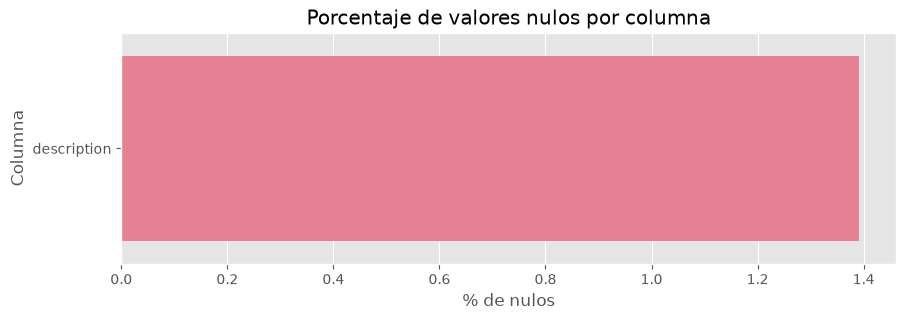

In [48]:
# Visualizacion del porcentaje de nulos por columna
pct = (df.isnull().mean() * 100).sort_values(ascending=False)
pct = pct[pct > 0]

if len(pct) > 0:
    plt.figure(figsize=(10, max(3, 0.4 * len(pct))))
    sns.barplot(x=pct.values, y=pct.index)
    plt.title("Porcentaje de valores nulos por columna")
    plt.xlabel("% de nulos")
    plt.ylabel("Columna")
    plt.show()
else:
    print("No hay columnas con valores nulos.")

## 5. Duplicados

Analizamos duplicados a tres niveles. **Nota:** el notebook principal usa
`df[df.duplicated]` (sin paréntesis), lo que es un error; aquí usamos
`df.duplicated()` correctamente.

- **Exactos**: filas idénticas en todas las columnas (candidatas a eliminar).
- **Por `video_id`**: un mismo video puede aparecer en varios días de tendencia, así
  que no todos son errores; es esperable por la naturaleza del dataset.
- **Por `(video_id, trending_date)`**: si existen, sí serían registros redundantes del
  mismo video en el mismo día.

In [49]:
# Duplicados a distintos niveles (df.duplicated() CON parentesis)
dup_exactos = df.duplicated().sum()
dup_video = df.duplicated(subset=["video_id"]).sum()
dup_video_fecha = df.duplicated(subset=["video_id", "trending_date"]).sum()

print(f"Duplicados exactos (todas las columnas): {dup_exactos}")
print(f"Duplicados por video_id: {dup_video}  (esperable: un video en varios dias)")
print(f"Duplicados por (video_id, trending_date): {dup_video_fecha}  (redundantes reales)")

Duplicados exactos (todas las columnas): 1
Duplicados por video_id: 34598  (esperable: un video en varios dias)
Duplicados por (video_id, trending_date): 50  (redundantes reales)


In [50]:
# Ver las filas exactamente duplicadas (original + copia) si las hay
duplicados_exactos = df[df.duplicated(keep=False)]
print(f"Filas involucradas en duplicados exactos: {len(duplicados_exactos)}")
duplicados_exactos.head(10)

Filas involucradas en duplicados exactos: 2


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
34777,nRc0kmOYgzQ,18.15.05,"We built the Infinity Gauntlet with 25,000 mag...",Vat19,24,2018-05-12T11:30:03.000Z,"vat19|""vat19 nanodots""|""vat19 infinity gauntle...",2227658,29191,1157,4092,https://i.ytimg.com/vi/nRc0kmOYgzQ/default.jpg,False,False,False,"NanoDots master builder, Edo, turned a huge pi...",Louisiana,30.39183,-92.329102,POINT (-92.32910200000001 30.39183),Entertainment
34926,nRc0kmOYgzQ,18.15.05,"We built the Infinity Gauntlet with 25,000 mag...",Vat19,24,2018-05-12T11:30:03.000Z,"vat19|""vat19 nanodots""|""vat19 infinity gauntle...",2227658,29191,1157,4092,https://i.ytimg.com/vi/nRc0kmOYgzQ/default.jpg,False,False,False,"NanoDots master builder, Edo, turned a huge pi...",Louisiana,30.39183,-92.329102,POINT (-92.32910200000001 30.39183),Entertainment


In [51]:
duplicados_video_fecha = df[df.duplicated(subset=["video_id", "trending_date"], keep=False)]
print(f"Filas involucradas en duplicados por video_id y trending_date: {len(duplicados_video_fecha)}")
duplicados_video_fecha.sort_values("video_id", ascending=False).head(10)

Filas involucradas en duplicados por video_id y trending_date: 100


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
34945,zcEE8J2Bqa8,18.15.05,The Goblin - JACK AND DEAN,Jack and Dean,23,2018-05-11T18:27:01.000Z,"Jack and Dean|""OMFGItsJackAndDean""|""Jack Howar...",165617,20572,140,1407,https://i.ytimg.com/vi/zcEE8J2Bqa8/default.jpg,False,False,False,That? That's a goblin living under the stairs....,North Carolina,35.782169,-80.793457,POINT (-80.793457 35.782169),Comedy
34796,zcEE8J2Bqa8,18.15.05,The Goblin - JACK AND DEAN,Jack and Dean,23,2018-05-11T18:27:01.000Z,"Jack and Dean|""OMFGItsJackAndDean""|""Jack Howar...",165617,20572,140,1407,https://i.ytimg.com/vi/zcEE8J2Bqa8/default.jpg,False,False,False,That? That's a goblin living under the stairs....,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Comedy
34793,y_WoOYybCro,18.15.05,How I Became The Fresh Prince of Bel-Air | STO...,Will Smith,24,2018-05-10T16:08:58.000Z,"comedy|""entertainment""|""will smith""|""will""|""sm...",2055638,120377,752,4872,https://i.ytimg.com/vi/y_WoOYybCro/default.jpg,False,False,False,"The full story of how an ex-girlfriend, Arseni...",Rhode Island,41.700001,-71.500000,POINT (-71.5 41.700001),Entertainment
34942,y_WoOYybCro,18.15.05,How I Became The Fresh Prince of Bel-Air | STO...,Will Smith,24,2018-05-10T16:08:58.000Z,"comedy|""entertainment""|""will smith""|""will""|""sm...",2055638,120377,752,4872,https://i.ytimg.com/vi/y_WoOYybCro/default.jpg,False,False,False,"The full story of how an ex-girlfriend, Arseni...",Massachusetts,42.407211,-71.382439,POINT (-71.38243900000001 42.407211),Entertainment
34903,xhs8tf1v__w,18.15.05,Terry Crews Answers the Web's Most Searched Qu...,WIRED,24,2018-05-14T16:00:29.000Z,"autocomplete|""deadpool 2""|""google autocomplete...",343967,16988,132,1308,https://i.ytimg.com/vi/xhs8tf1v__w/default.jpg,False,False,False,Terry Crews takes the WIRED Autocomplete Inter...,Hawaii,19.741755,-155.844437,POINT (-155.844437 19.741755),Entertainment
34754,xhs8tf1v__w,18.15.05,Terry Crews Answers the Web's Most Searched Qu...,WIRED,24,2018-05-14T16:00:29.000Z,"autocomplete|""deadpool 2""|""google autocomplete...",343967,16988,132,1308,https://i.ytimg.com/vi/xhs8tf1v__w/default.jpg,False,False,False,Terry Crews takes the WIRED Autocomplete Inter...,Mississippi,33.000000,-90.000000,POINT (-90 33),Entertainment
34918,xTrwT0jSUg0,18.15.05,Mother Knows Best - SNL,Saturday Night Live,24,2018-05-13T05:06:11.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""SNL...",1248343,15750,1919,1261,https://i.ytimg.com/vi/xTrwT0jSUg0/default.jpg,False,False,False,"Three mother-child pairs (Cecily Strong, Aidy ...",California,36.778259,-119.417931,POINT (-119.417931 36.778259),Entertainment
34769,xTrwT0jSUg0,18.15.05,Mother Knows Best - SNL,Saturday Night Live,24,2018-05-13T05:06:11.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""SNL...",1248343,15750,1919,1261,https://i.ytimg.com/vi/xTrwT0jSUg0/default.jpg,False,False,False,"Three mother-child pairs (Cecily Strong, Aidy ...",Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Entertainment
34790,vjSohj-Iclc,18.15.05,"Getting some air, Atlas?",BostonDynamics,28,2018-05-10T19:56:28.000Z,"Dynamic robots|""Boston Dynamics""|""humanoid rob...",5650991,76461,2666,12187,https://i.ytimg.com/vi/vjSohj-Iclc/default.jpg,False,False,False,NaN,Wisconsin,44.500000,-89.500000,POINT (-89.5 44.5),Science & Technology
34939,vjSohj-Iclc,18.15.05,"Getting some air, Atlas?",BostonDynamics,28,2018-05-10T19:56:28.000Z,"Dynamic robots|""Boston Dynamics""|""humanoid rob...",5650991,76461,2666,12187,https://i.ytimg.com/vi/vjSohj-Iclc/default.jpg,False,False,False,NaN,North Carolina,35.782169,-80.793457,POINT (-80.793457 35.782169),Science & Technology


## 6. Distribuciones y outliers

Visualizamos la distribución de las métricas de engagement en escala normal y
logarítmica (`log1p`), ya que están muy sesgadas. Los boxplots ayudan a ver outliers
y con el método **IQR** cuantificamos cuántos valores caen fuera de
`[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`. También contamos los ceros por variable.

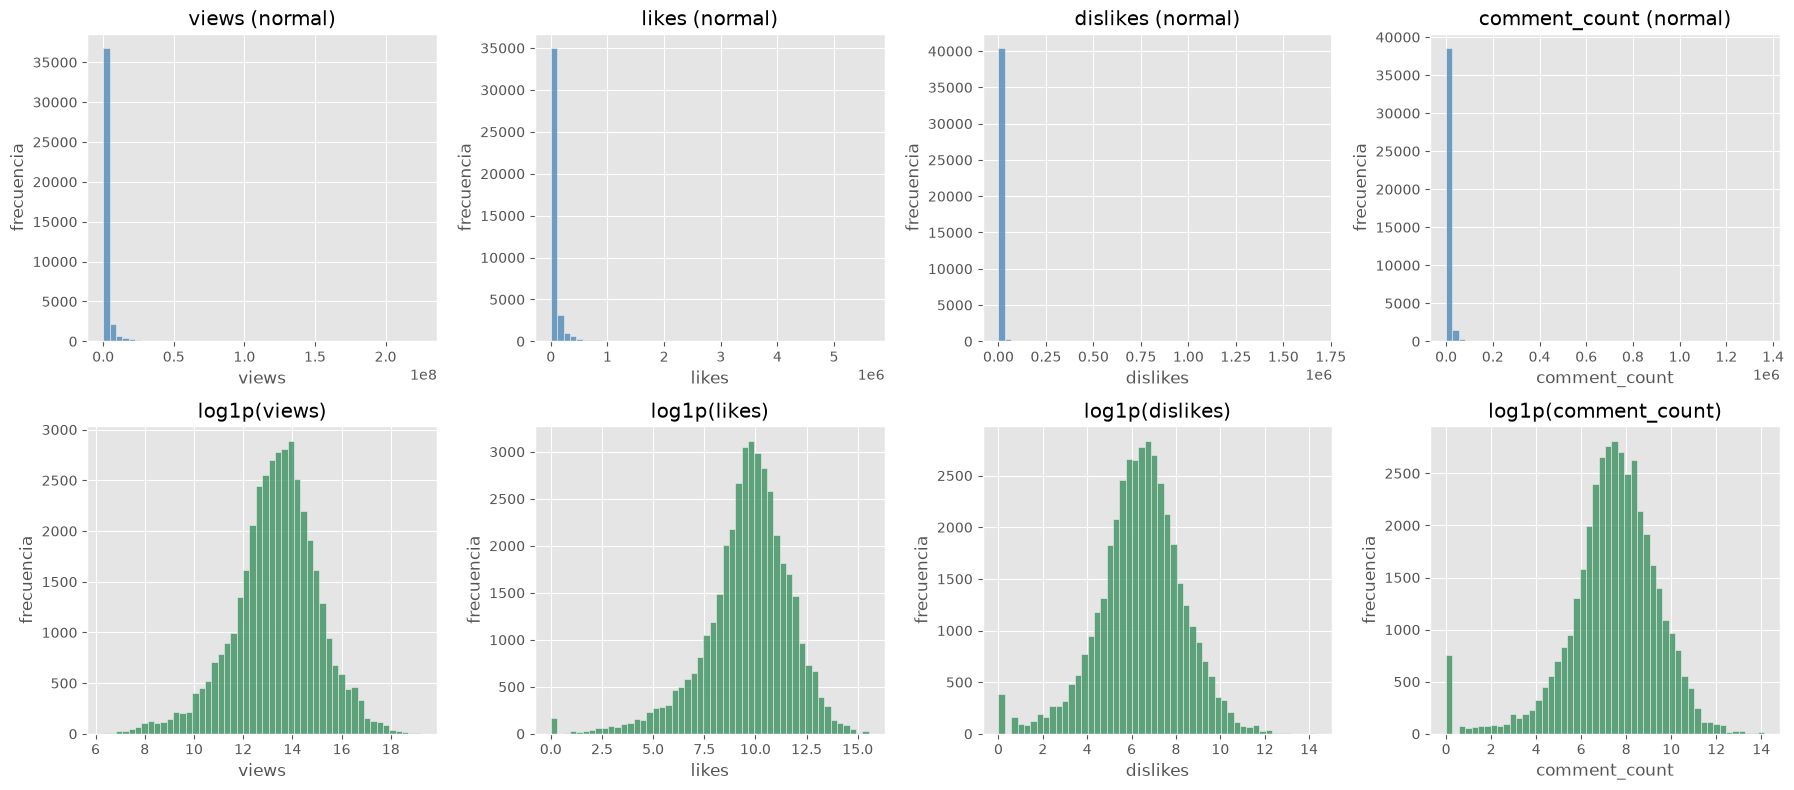

In [52]:
# Histogramas: escala normal (fila superior) vs log1p (fila inferior)
fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 8))
for j, col in enumerate(num_cols):
    sns.histplot(df[col], bins=50, ax=axes[0, j], color="steelblue")
    axes[0, j].set_title(f"{col} (normal)")
    axes[0, j].set_ylabel("frecuencia")

    sns.histplot(np.log1p(df[col]), bins=50, ax=axes[1, j], color="seagreen")
    axes[1, j].set_title(f"log1p({col})")
    axes[1, j].set_ylabel("frecuencia")
plt.tight_layout()
plt.show()

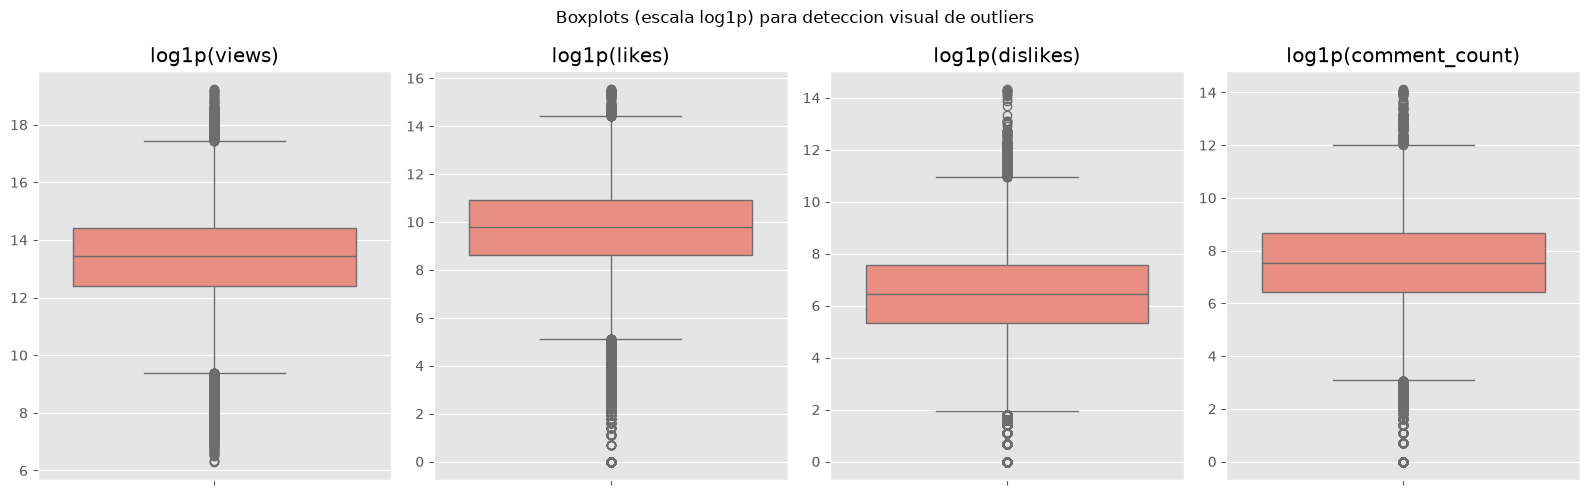

In [53]:
# Boxplots en escala logaritmica para visualizar outliers
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 5))
for j, col in enumerate(num_cols):
    sns.boxplot(y=np.log1p(df[col]), ax=axes[j], color="salmon")
    axes[j].set_title(f"log1p({col})")
    axes[j].set_ylabel("")
plt.suptitle("Boxplots (escala log1p) para deteccion visual de outliers")
plt.tight_layout()
plt.show()

In [54]:
# Deteccion de outliers por IQR y conteo de ceros
def resumen_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((serie < low) | (serie > high)).sum()
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "limite_inf": low, "limite_sup": high,
        "n_outliers": int(n_out),
        "%_outliers": round(n_out / len(serie) * 100, 2),
        "n_ceros": int((serie == 0).sum()),
    })

pd.DataFrame({c: resumen_iqr(df[c]) for c in num_cols}).T

,Q1,Q3,IQR,limite_inf,limite_sup,n_outliers,%_outliers,n_ceros
views,242329.0,1823157.0,1580828.0,-2128913.0,4194399.0,4499.0,10.99,0.0
likes,5424.0,55417.0,49993.0,-69565.5,130406.5,5136.0,12.54,172.0
dislikes,202.0,1938.0,1736.0,-2402.0,4542.0,5288.0,12.91,383.0
comment_count,614.0,5755.0,5141.0,-7097.5,13466.5,5089.0,12.43,760.0


## 6.5 Distribuciones univariadas (numéricas y categóricas)

Vista compacta para complementar lo anterior: una grilla de histogramas de las
variables numéricas (en escala `log1p`, por el sesgo) y gráficos de barras de las
principales variables categóricas (usando top-N para no saturar).

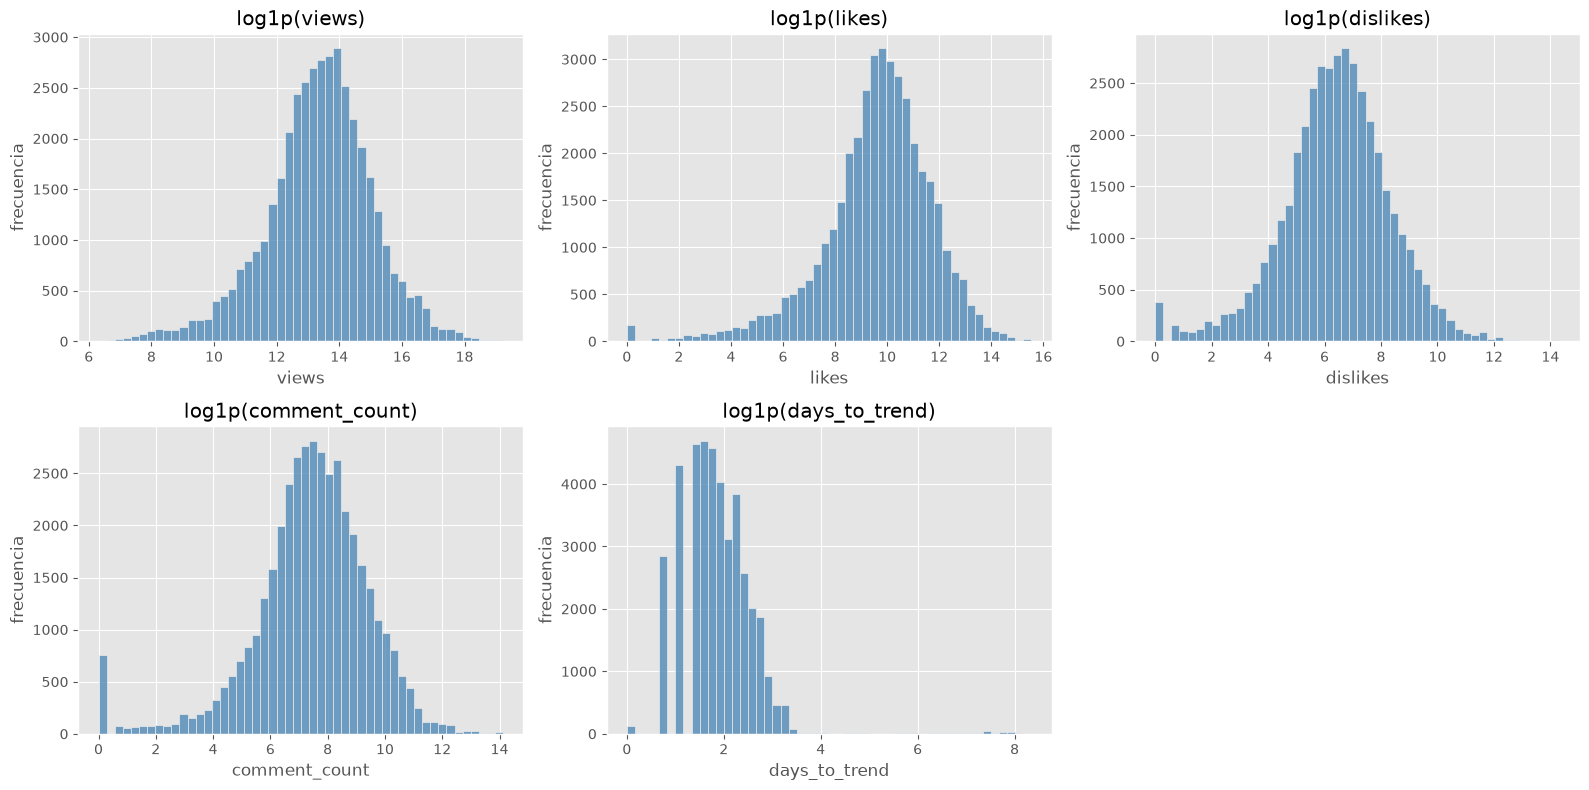

In [55]:
# days_to_trend (comparacion solo por fecha, como la correccion aplicada) para tenerlo disponible
_trend = pd.to_datetime(df["trending_date"], format="%y.%d.%m", errors="coerce")
_pub = pd.to_datetime(df["publish_time"], errors="coerce", utc=True).dt.tz_localize(None)
df["days_to_trend"] = (_trend.dt.normalize() - _pub.dt.normalize()).dt.days

# Histogramas de variables numericas (escala log1p por el sesgo), en una grilla compacta
num_vars = ["views", "likes", "dislikes", "comment_count", "days_to_trend"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_vars):
    serie = df[col].clip(lower=0)
    sns.histplot(np.log1p(serie), bins=50, ax=ax, color="steelblue")
    ax.set_title(f"log1p({col})")
    ax.set_ylabel("frecuencia")
axes.flat[-1].axis("off")  # celda sobrante
plt.tight_layout()
plt.show()

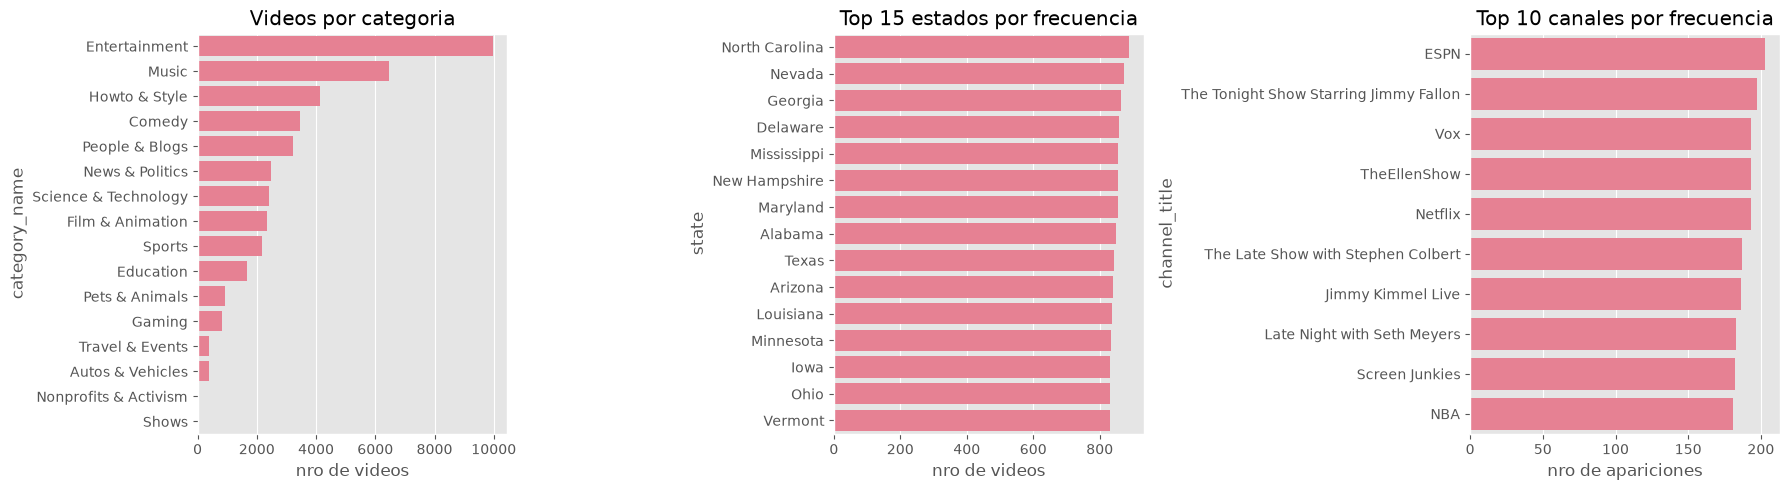

In [56]:
# Graficos de barras para variables categoricas (top-N para no saturar)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_counts = df["category_name"].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[0])
axes[0].set_title("Videos por categoria")
axes[0].set_xlabel("nro de videos")

state_counts = df["state"].value_counts().head(15)
sns.barplot(x=state_counts.values, y=state_counts.index, ax=axes[1])
axes[1].set_title("Top 15 estados por frecuencia")
axes[1].set_xlabel("nro de videos")

channel_counts = df["channel_title"].value_counts().head(10)
sns.barplot(x=channel_counts.values, y=channel_counts.index, ax=axes[2])
axes[2].set_title("Top 10 canales por frecuencia")
axes[2].set_xlabel("nro de apariciones")

plt.tight_layout()
plt.show()

## 7. Correlaciones

Matriz de correlación entre las métricas numéricas (sobre los valores `log1p` para
reducir el efecto del sesgo) y diagramas de dispersión de `views` frente a las demás
métricas. Esto anticipa la viabilidad de un modelo de regresión.

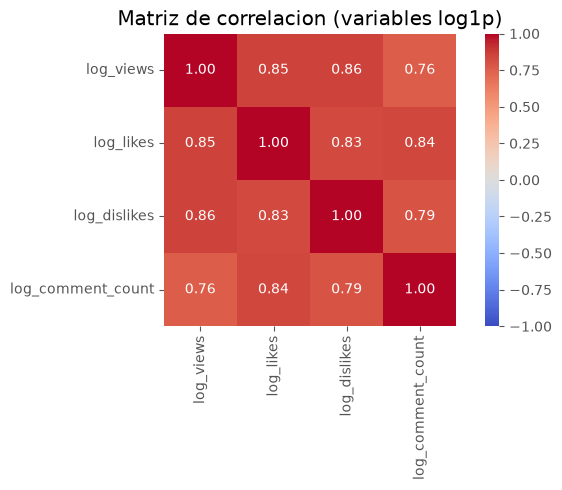

In [57]:
# Matriz de correlacion sobre las variables log-transformadas
log_df = np.log1p(df[num_cols]).add_prefix("log_")
corr = log_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlacion (variables log1p)")
plt.tight_layout()
plt.show()

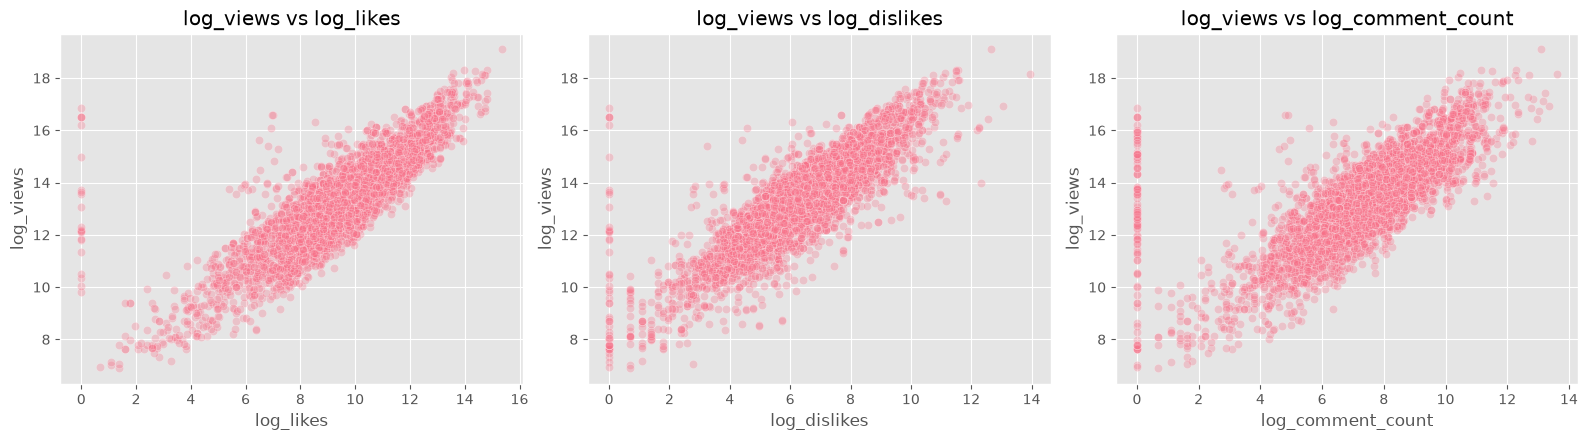

In [58]:
# Dispersion de log_views frente a las otras metricas (muestra para agilizar el ploteo)
muestra = log_df.sample(min(5000, len(log_df)), random_state=42)
otras = [c for c in log_df.columns if c != "log_views"]

fig, axes = plt.subplots(1, len(otras), figsize=(16, 4.5))
for ax, col in zip(axes, otras):
    sns.scatterplot(x=muestra[col], y=muestra["log_views"], alpha=0.3, ax=ax)
    ax.set_title(f"log_views vs {col}")
plt.tight_layout()
plt.show()

## 7.5 Variables que discriminan el target (`likes`)

Medimos qué variables **separan** mejor el comportamiento del target `likes`, dejando
de lado las limitaciones del dataset (se incluyen incluso variables con fuga potencial
—`views`, `dislikes`, `comment_count`— o de geografía aleatoria —`state`—, solo para
contrastar su poder discriminante):

- **Numéricas**: correlación de **Spearman** con `log_likes` (robusta a la asimetría).
- **Categóricas**: razón de correlación **eta² = SS_between / SS_total** (fracción de la
  varianza de `log_likes` explicada por la variable). Se espera que `state` salga ≈ 0
  (aleatoria) y `category_name` bastante mayor.

> Nota: esta sección mide separación del target sin filtrar por leakage/aleatoriedad;
> esos caveats se discuten aparte y condicionan qué variables entran realmente al modelo.

In [59]:
# Preparar target y features auxiliares
log_likes = np.log1p(df["likes"])
denom = df["views"].replace(0, np.nan)
df["dislike_view_ratio"] = (df["dislikes"] / denom).fillna(0)
df["comment_view_ratio"] = (df["comment_count"] / denom).fillna(0)

# Discriminacion de variables NUMERICAS: |Spearman| con log_likes
num_feats = ["views", "dislikes", "comment_count", "days_to_trend",
             "dislike_view_ratio", "comment_view_ratio"]
spearman = (
    pd.Series({c: df[c].corr(log_likes, method="spearman") for c in num_feats})
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
tabla_num = spearman.rename("spearman_vs_log_likes").to_frame()
tabla_num["|spearman|"] = tabla_num["spearman_vs_log_likes"].abs().round(3)
tabla_num.round(3)

,spearman_vs_log_likes,|spearman|
comment_count,0.878,0.878
views,0.863,0.863
dislikes,0.799,0.799
days_to_trend,0.249,0.249
comment_view_ratio,0.152,0.152
dislike_view_ratio,0.052,0.052


In [60]:
# Discriminacion de variables CATEGORICAS: razon de correlacion eta^2 con log_likes
def eta_squared(cat, y):
    d = pd.DataFrame({"c": cat.values, "y": y.values}).dropna()
    grand = d["y"].mean()
    ss_total = ((d["y"] - grand) ** 2).sum()
    if ss_total == 0:
        return np.nan
    ss_between = d.groupby("c")["y"].apply(lambda g: len(g) * (g.mean() - grand) ** 2).sum()
    return ss_between / ss_total

cat_feats = ["category_name", "state", "channel_title"]
tabla_cat = (
    pd.Series({c: eta_squared(df[c], log_likes) for c in cat_feats}, name="eta2_vs_log_likes")
    .sort_values(ascending=False)
    .round(4)
    .to_frame()
)
tabla_cat

,eta2_vs_log_likes
channel_title,0.8395
category_name,0.1533
state,0.0010


### 7.5.1 Agrupación de `category_name` por impacto (para one-hot)

`category_name` tiene 16 niveles: un one-hot directo genera ~15 dummies y `channel_title`
(2207 niveles) es inviable. Como alternativa, agrupamos las categorías en **4 niveles según
su impacto** en `log_likes`, lo que permite un one-hot compacto (3 dummies, referencia = `Bajo`)
sin perder casi poder explicativo. Abajo evidenciamos que los 4 grupos forman escalones
limpios y que el `eta²` apenas baja al pasar de 16 categorías a 4 grupos.

Esta agrupación es la que consume el notebook de limpieza (`limpieza.ipynb`) para construir
las variables `catgrupo_*`.

In [61]:
# Agrupacion de categorias en 4 niveles por impacto en log_likes
GRUPO_CATEGORIA = {
    "Music": "Alto", "Gaming": "Alto", "Comedy": "Alto",
    "Entertainment": "MedioAlto", "Howto & Style": "MedioAlto",
    "Film & Animation": "MedioAlto", "People & Blogs": "MedioAlto",
    "Education": "MedioAlto", "Science & Technology": "MedioAlto",
    "Pets & Animals": "MedioAlto", "Shows": "MedioAlto",
    "Sports": "MedioBajo", "Travel & Events": "MedioBajo",
    "News & Politics": "Bajo", "Autos & Vehicles": "Bajo",
    "Nonprofits & Activism": "Bajo",
}
ORDEN_GRUPOS = ["Bajo", "MedioBajo", "MedioAlto", "Alto"]

# Tabla de impacto por categoria (ordenada por media de log_likes)
tabla_impacto = (
    df.assign(_ll=log_likes)
      .groupby("category_name")
      .agg(n=("likes", "size"),
           mediana_likes=("likes", "median"),
           media_log_likes=("_ll", "mean"))
      .sort_values("media_log_likes", ascending=False)
)
tabla_impacto["grupo"] = tabla_impacto.index.map(GRUPO_CATEGORIA)
print("Impacto por categoria (ordenado por media log_likes):")
print(tabla_impacto.round(2))

# Comparacion de poder discriminante: 16 categorias vs 4 grupos
cat_grupo = pd.Series(
    pd.Categorical(df["category_name"].map(GRUPO_CATEGORIA), categories=ORDEN_GRUPOS, ordered=True)
)
eta_16 = eta_squared(df["category_name"], log_likes)
eta_4 = eta_squared(cat_grupo, log_likes)
print(f"\neta^2 con 16 categorias: {eta_16:.4f}")
print(f"eta^2 con 4 grupos     : {eta_4:.4f}  ({eta_4 / eta_16 * 100:.1f}% del original)")

Impacto por categoria (ordenado por media log_likes):
                          n  mediana_likes  media_log_likes      grupo
category_name                                                         
Music                  6472        62280.5            10.81       Alto
Gaming                  817        51057.0            10.54       Alto
Comedy                 3457        30214.0            10.15       Alto
Howto & Style          4146        21492.5             9.78  MedioAlto
Film & Animation       2345        25176.0             9.71  MedioAlto
People & Blogs         3210        19438.0             9.61  MedioAlto
Shows                    57        21537.0             9.50  MedioAlto
Education              1656        13508.5             9.47  MedioAlto
Entertainment          9964        16234.0             9.44  MedioAlto
Science & Technology   2401        16328.0             9.31  MedioAlto
Pets & Animals          920        14431.5             9.28  MedioAlto
Travel & Events        

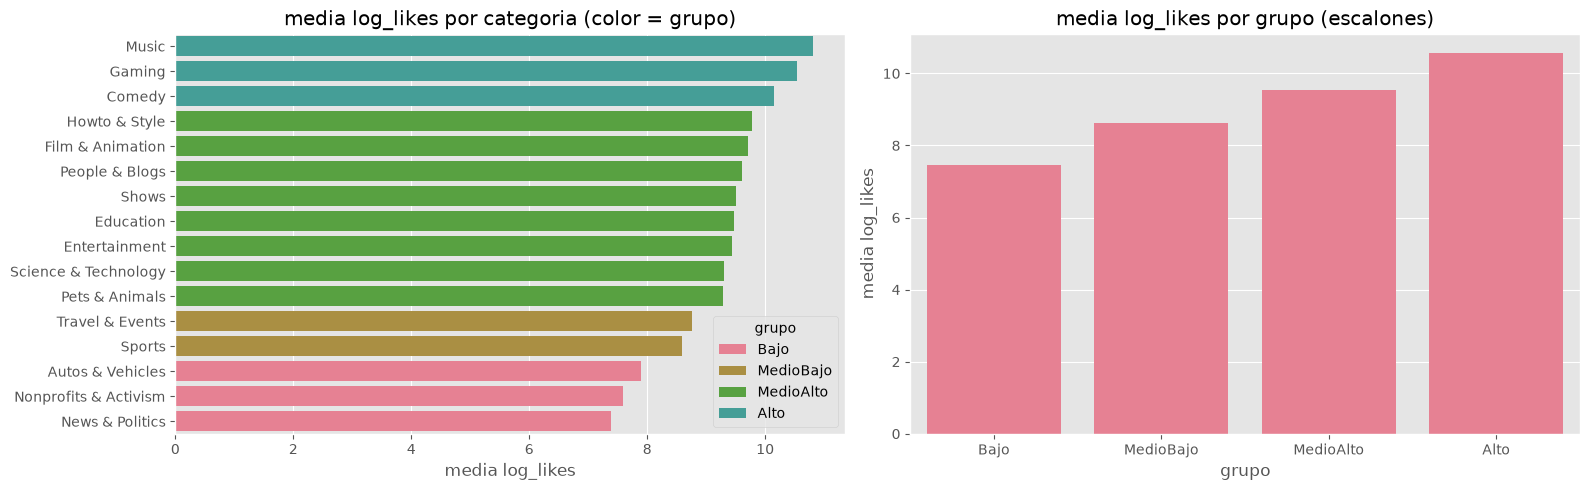

In [62]:
# Visual: escalones de impacto por categoria y por grupo
tp = tabla_impacto.reset_index()
medias_grupo = (
    pd.Series(log_likes.values, index=cat_grupo.values)
    .groupby(level=0).mean().reindex(ORDEN_GRUPOS)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=tp, x="media_log_likes", y="category_name",
            hue="grupo", hue_order=ORDEN_GRUPOS, dodge=False, ax=axes[0])
axes[0].set_title("media log_likes por categoria (color = grupo)")
axes[0].set_xlabel("media log_likes")
axes[0].set_ylabel("")
axes[0].legend(title="grupo", loc="lower right")

sns.barplot(x=medias_grupo.index, y=medias_grupo.values, order=ORDEN_GRUPOS, ax=axes[1])
axes[1].set_title("media log_likes por grupo (escalones)")
axes[1].set_xlabel("grupo")
axes[1].set_ylabel("media log_likes")

plt.tight_layout()
plt.show()

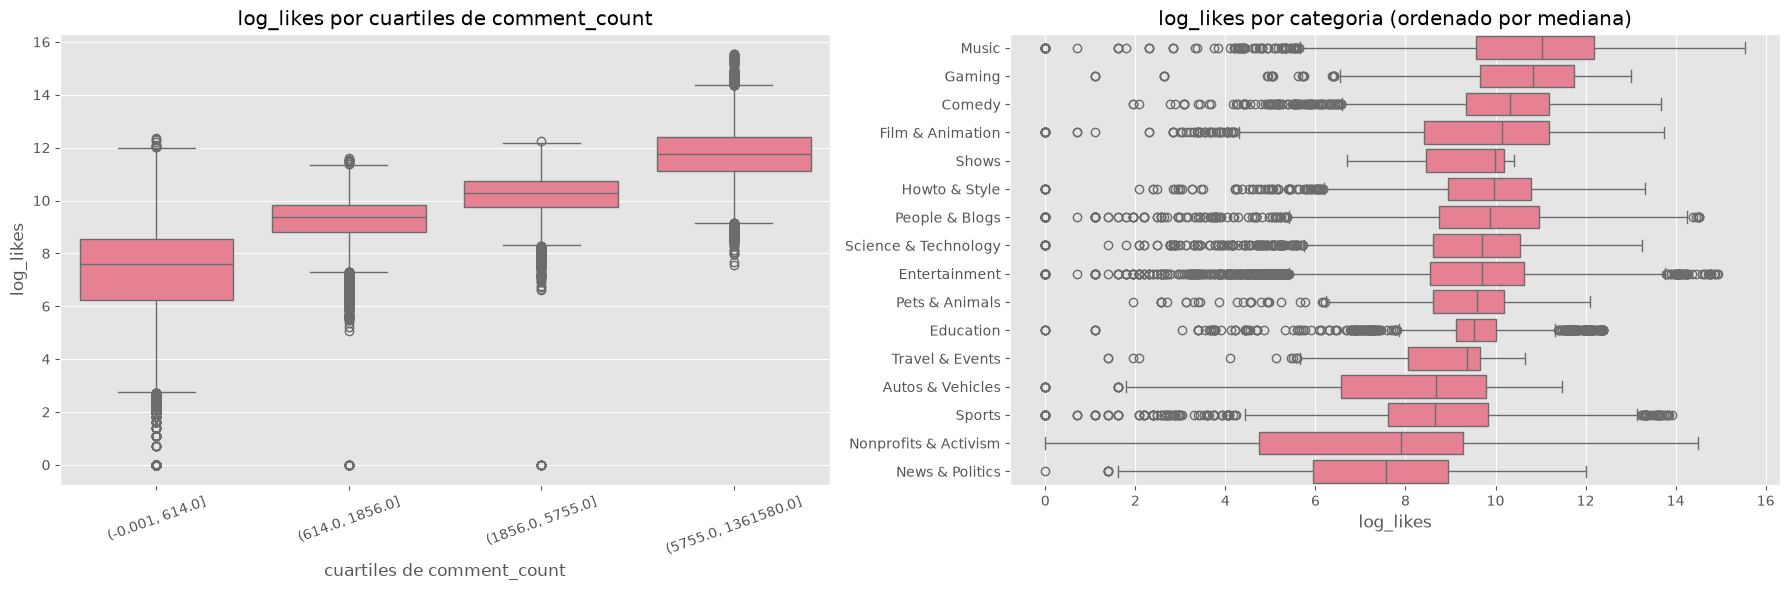

In [63]:
# Visual: como se separa el target segun las variables mas discriminantes
top_num = spearman.abs().idxmax()  # numerica mas discriminante

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (a) log_likes por cuartiles de la numerica mas discriminante
cuartiles = pd.qcut(df[top_num], q=4, duplicates="drop")
sns.boxplot(x=cuartiles, y=log_likes, ax=axes[0])
axes[0].set_title(f"log_likes por cuartiles de {top_num}")
axes[0].set_xlabel(f"cuartiles de {top_num}")
axes[0].set_ylabel("log_likes")
axes[0].tick_params(axis="x", rotation=20)

# (b) log_likes por categoria (ordenado por mediana)
orden = df.groupby("category_name")["likes"].median().sort_values(ascending=False).index
sns.boxplot(x=log_likes, y=df["category_name"], order=orden, ax=axes[1])
axes[1].set_title("log_likes por categoria (ordenado por mediana)")
axes[1].set_xlabel("log_likes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 8. Temporalidad

Parseamos `trending_date` (formato `YY.DD.MM`) y `publish_time` para conocer el rango
temporal cubierto y construir `days_to_trend` (días entre la publicación y la entrada
en tendencia). Los valores **negativos** de `days_to_trend` son inconsistencias
(tendencia antes de publicar) que se marcan para la limpieza.

In [64]:
# Parseo de fechas (sin modificar el df original; usamos variables auxiliares)
trending_dt = pd.to_datetime(df["trending_date"], format="%y.%d.%m", errors="coerce").dt.date
publish_dt = pd.to_datetime(df["publish_time"], errors="coerce", utc=True).dt.tz_localize(None).dt.date

print("Rango trending_date:", trending_dt.min(), "->", trending_dt.max())
print("Rango publish_time :", publish_dt.min(), "->", publish_dt.max())
print("Fechas de tendencia no parseables:", int(trending_dt.isna().sum()))
print("Fechas de publicacion no parseables:", int(publish_dt.isna().sum()))

Rango trending_date: 2017-11-14 -> 2018-06-14
Rango publish_time : 2006-07-23 -> 2018-06-14
Fechas de tendencia no parseables: 0
Fechas de publicacion no parseables: 0


days_to_trend -> min: 0, mediana: 5.0, max: 4215
Registros con days_to_trend NEGATIVO (inconsistentes): 0


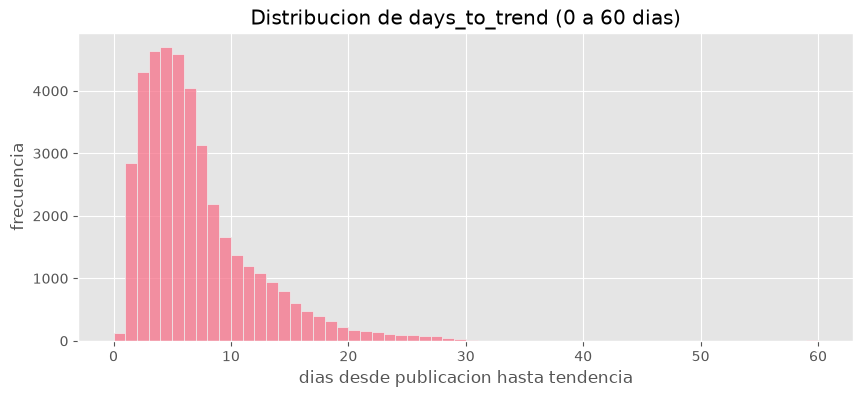

In [65]:
# days_to_trend y deteccion de valores negativos (inconsistencias)
days_to_trend = (trending_dt - publish_dt).apply(lambda x: x.days if pd.notnull(x) else np.nan)
n_negativos = int((days_to_trend < 0).sum())

print(f"days_to_trend -> min: {days_to_trend.min()}, mediana: {days_to_trend.median()}, max: {days_to_trend.max()}")
print(f"Registros con days_to_trend NEGATIVO (inconsistentes): {n_negativos}")

plt.figure(figsize=(10, 4))
sns.histplot(days_to_trend[(days_to_trend >= 0) & (days_to_trend <= 60)], bins=60)
plt.title("Distribucion de days_to_trend (0 a 60 dias)")
plt.xlabel("dias desde publicacion hasta tendencia")
plt.ylabel("frecuencia")
plt.show()

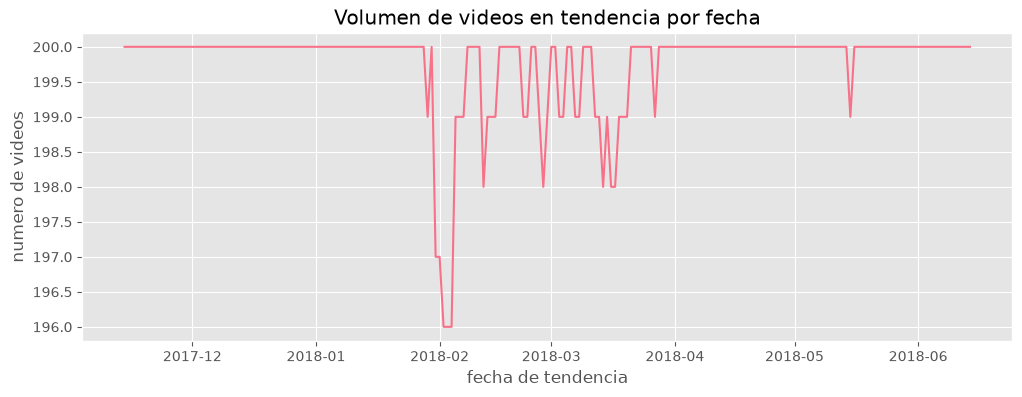

In [66]:
# Volumen de videos en tendencia a lo largo del tiempo
volumen = trending_dt.value_counts().sort_index()

plt.figure(figsize=(12, 4))
volumen.plot()
plt.title("Volumen de videos en tendencia por fecha")
plt.xlabel("fecha de tendencia")
plt.ylabel("numero de videos")
plt.show()

## 9. Validación de reglas de negocio

Implementamos como código las reglas esbozadas en `scripts/eda.py`. Cada regla define
una condición que las filas *válidas* deben cumplir; contamos las **violaciones**:

1. `likes <= views` y `dislikes <= views` — no puede haber más reacciones que vistas.
2. `trending_date >= publish_time` — un video no puede ser tendencia antes de publicarse.
3. `comment_count <= views` — no puede haber más comentarios que vistas.
4. `comments_disabled == True` implica `comment_count == 0`.
5. `ratings_disabled == True` implica `likes == 0` y `dislikes == 0`.

In [67]:
# Normalizamos las columnas booleanas por si vienen como texto ("True"/"False")
def a_bool(serie):
    if serie.dtype == bool:
        return serie
    return serie.astype(str).str.strip().str.lower().isin(["true", "1", "yes"])

comments_disabled = a_bool(df["comments_disabled"])
ratings_disabled = a_bool(df["ratings_disabled"])

# Cada entrada: nombre de la regla -> mascara booleana de VIOLACIONES
violaciones = {
    "R1a: likes > views": df["likes"] > df["views"],
    "R1b: dislikes > views": df["dislikes"] > df["views"],
    "R2: trending < publish": days_to_trend < 0,
    "R3: comment_count > views": df["comment_count"] > df["views"],
    "R4: comments_disabled pero comment_count>0": comments_disabled & (df["comment_count"] > 0),
    "R5: ratings_disabled pero likes/dislikes>0": ratings_disabled & ((df["likes"] > 0) | (df["dislikes"] > 0)),
}

resumen_reglas = pd.DataFrame({
    "n_violaciones": {k: int(v.sum()) for k, v in violaciones.items()},
})
resumen_reglas["%_violaciones"] = (resumen_reglas["n_violaciones"] / len(df) * 100).round(3)
resumen_reglas

,n_violaciones,%_violaciones
R1a: likes > views,0,0.0
R1b: dislikes > views,0,0.0
R2: trending < publish,0,0.0
R3: comment_count > views,0,0.0
R4: comments_disabled pero comment_count>0,0,0.0
R5: ratings_disabled pero likes/dislikes>0,0,0.0


In [68]:
# Filas que violan AL MENOS una regla (candidatas a revision/limpieza)
mascara_cualquiera = pd.concat(violaciones.values(), axis=1).any(axis=1)
print(f"Filas que violan al menos una regla: {int(mascara_cualquiera.sum())} "
      f"({mascara_cualquiera.mean() * 100:.3f}% del total)")

cols_muestra = ["video_id", "views", "likes", "dislikes", "comment_count",
                "comments_disabled", "ratings_disabled", "trending_date", "publish_time"]
df.loc[mascara_cualquiera, cols_muestra].head(10)

Filas que violan al menos una regla: 0 (0.000% del total)


,video_id,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,trending_date,publish_time


In [69]:
# Resumen numerico consolidado (para el checklist de limpieza)
print("=== RESUMEN PARA LA LIMPIEZA ===")
print(f"Filas totales: {len(df):,}")
print(f"Duplicados exactos: {dup_exactos}")
print(f"Duplicados (video_id, trending_date): {dup_video_fecha}")
print(f"Columnas con nulos: {int((df.isnull().sum() > 0).sum())}")
print(f"days_to_trend negativos: {n_negativos}")
print(f"Filas que violan alguna regla de negocio: {int(mascara_cualquiera.sum())}")
print("\nNulos por columna (solo > 0):")
print(tabla_nulos[tabla_nulos['n_nulos'] > 0].to_string())

=== RESUMEN PARA LA LIMPIEZA ===
Filas totales: 40,949
Duplicados exactos: 1
Duplicados (video_id, trending_date): 50
Columnas con nulos: 1
days_to_trend negativos: 0
Filas que violan alguna regla de negocio: 0

Nulos por columna (solo > 0):
             n_nulos  %_nulos
description      570     1.39


## 10. Resumen de hallazgos para la limpieza

A partir de esta exploración, la fase de **limpieza** debería considerar (ajustar según
los números obtenidos al ejecutar el notebook):

- **Duplicados**: eliminar duplicados exactos y revisar los duplicados por
  `(video_id, trending_date)` si existen, pues estos representan duplicados reales al solo diferenciarse en "state", el cual fue introducido de forma aleatoria. Mantener los duplicados por `video_id` que
  correspondan a días de tendencia distintos (comportamiento esperado).
- **Nulos**: tratar las columnas con nulos (p. ej. `description`), decidiendo entre
  imputar (texto vacío) o dejar el nulo según el uso posterior.
- **Outliers y sesgo**: las métricas de engagement están muy sesgadas a la derecha; se
  justifica aplicar `log1p` para el modelado en lugar de eliminar los valores extremos
  (son videos virales reales, no errores).
- **Consistencia temporal**: descartar o corregir los registros con `days_to_trend`
  negativo. Crear `days_to_trend` como variable derivada.
- **Reglas de negocio**: revisar las filas que violan alguna regla (likes/dislikes/
  comentarios mayores que las vistas, o flags `*_disabled` inconsistentes con sus
  conteos) y decidir si se corrigen o se eliminan.
- **Columnas**: evaluar la utilidad de columnas de alta cardinalidad o poco
  informativas para el análisis (`thumbnail_link`, `geometry`, `tags`).

> Siguiente paso: implementar estas decisiones en la fase de preparación/limpieza
> (por ejemplo en `scripts/limpieza.py` o en la sección correspondiente del notebook
> principal).

### 3. PREPARACIÓN Y VISUALIZACIÓN DE LOS DATOS
#### Preguntas a responder (Requerimientos de la Consultora):
Como parte del análisis exploratorio, buscaremos dar respuesta a las siguientes interrogantes clave para la consultora de marketing digital:

1. **¿Qué categorías de videos son las más vistas?**
2. **¿Qué categorías de videos son los que más gustan? ¿Y las que menos gustan?**
3. **¿Qué categorías de videos tienen la mejor proporción (ratio) de “Me gusta” / “No me gusta”?**
4. **¿Qué categorías de videos tienen la mejor proporción (ratio) de “Vistas” / “Comentarios”?**
5. **¿Cómo ha cambiado el volumen de los videos en tendencia a lo largo del tiempo?**
6. **¿Qué Canales de YouTube son tendencia más frecuentemente? ¿Y cuáles con menos frecuencia?**
7. **¿En qué Estados se presenta el mayor número de “Vistas”, “Me gusta” y “No me gusta”?**


---
#### Exploración y Visualización de los Datos
A continuación, procedemos a responder las preguntas planteadas:


## 1. Setup y carga


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

# Cargar dataset limpio
df_clean = pd.read_csv('dataset/USvideos_clean.csv')
df_base = pd.read_csv('dataset/USvideos_clean_base.csv', usecols=['video_id', 'trending_date', 'channel_title', 'state'])
df = pd.merge(df_clean, df_base, on=['video_id', 'trending_date'], how='left')

## <a id='1'></a>1. ¿Qué categorías de videos son las de mayor tendencia?


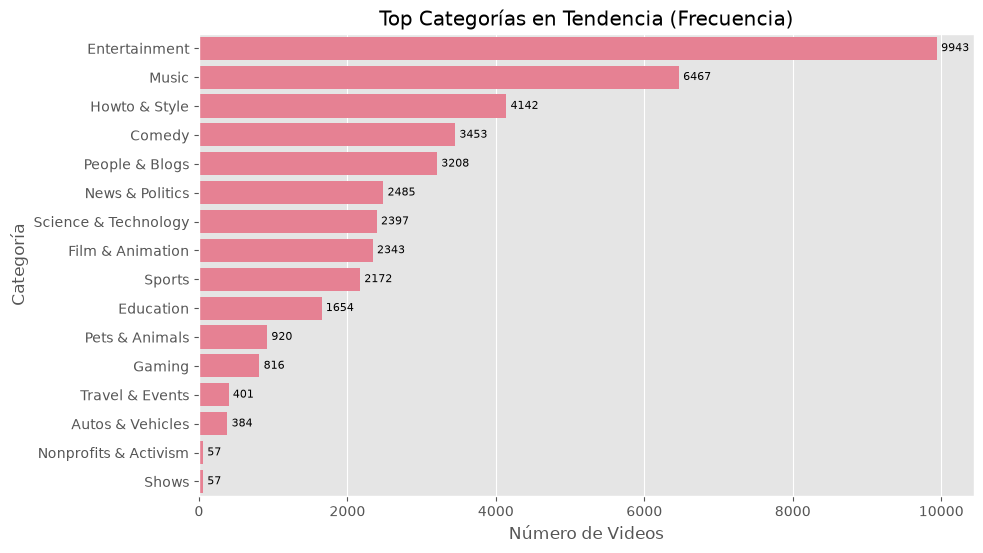

In [71]:
# 1. ¿Qué categorías de videos son las de mayor tendencia?
plt.figure(figsize=(10,6))
top_categories = df['category_name'].value_counts()
ax = sns.barplot(x=top_categories.values, y=top_categories.index)
ax.bar_label(ax.containers[0], fmt='%g', padding=3, size=8)
plt.title('Top Categorías en Tendencia (Frecuencia)')
plt.xlabel('Número de Videos')
plt.ylabel('Categoría')
plt.show()


**Análisis y Explicación del Gráfico 1:**
- **Observación:** El gráfico de barras horizontales muestra el volumen total de videos que lograron entrar en tendencia, agrupados por categoría.
- **Hallazgos:** La categoría de *Entertainment* (Entretenimiento) domina abrumadoramente el ecosistema de tendencias con **9,943 videos** (representando aproximadamente el **24.3%** del total de tendencias). Le sigue *Music* (Música) con **6,467 videos** y *People & Blogs* (Gente y Blogs).
- **Implicancia para el Negocio:** Al ser la categoría más masiva, "Entertainment" representa un mercado saturado pero inmenso. Pautar publicidad aquí asegura una exposición total, pero requiere un presupuesto mayor debido a la alta puja (bidding) por espacios publicitarios frente a competidores. 
- **Recomendación Estratégica:** Destinar un 60% del presupuesto de campañas masivas (awareness general) a creadores de "Entertainment" para garantizar el alcance de marca. En paralelo, explorar alianzas estratégicas en "People & Blogs" para patrocinios más orgánicos y económicos debido a la gran cercanía y confianza de estos creadores con su audiencia.


## <a id='2'></a>2. ¿Qué categorías de videos son los que más gustan? ¿Y las que menos gustan?


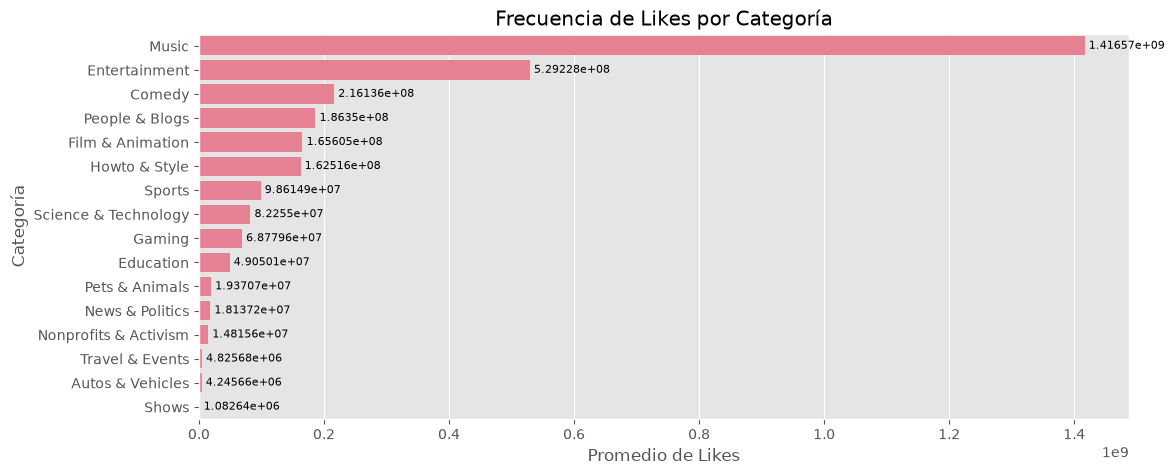

In [72]:
# 2. ¿Qué categorías gustan más y cuáles menos? (Suma de Likes por categoría)
plt.figure(figsize=(12,5))
likes_by_cat = df.groupby('category_name')['likes'].sum().sort_values(ascending=False)
ax = sns.barplot(x=likes_by_cat.values, y=likes_by_cat.index)
ax.bar_label(ax.containers[0], fmt='%g', padding=3, size=8)
plt.title('Frecuencia de Likes por Categoría')
plt.xlabel('Promedio de Likes')
plt.ylabel('Categoría')
plt.show()


/tmp/ipykernel_21634/92377312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dislikes_by_cat.values, y=dislikes_by_cat.index, palette='Reds_r')


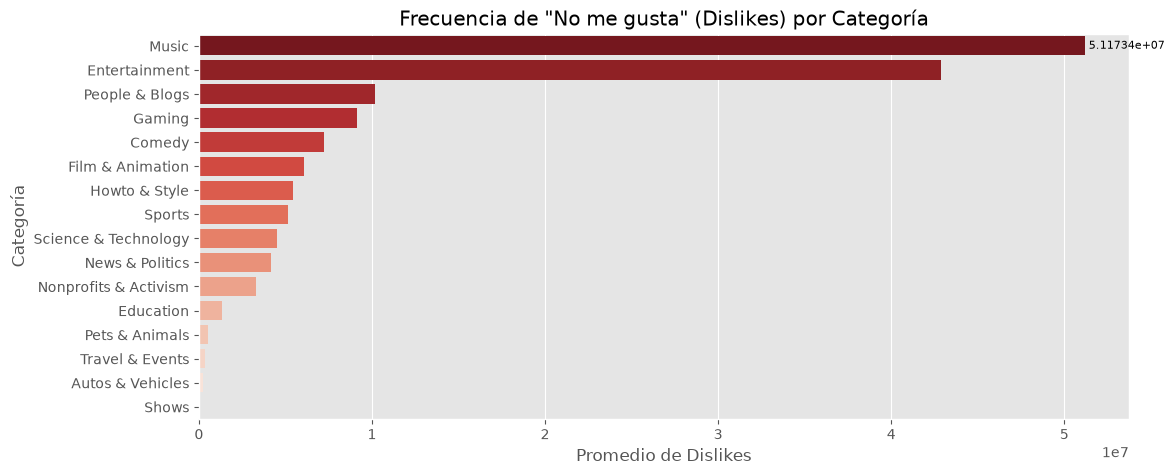

In [73]:
# 2 ¿Cuáles gustan menos? (Suma de Dislikes por categoría)
plt.figure(figsize=(12,5))
dislikes_by_cat = df.groupby('category_name')['dislikes'].sum().sort_values(ascending=False)
ax = sns.barplot(x=dislikes_by_cat.values, y=dislikes_by_cat.index, palette='Reds_r')
ax.bar_label(ax.containers[0], fmt='%g', padding=3, size=8)
plt.title('Frecuencia de "No me gusta" (Dislikes) por Categoría')
plt.xlabel('Promedio de Dislikes')
plt.ylabel('Categoría')
plt.show()

**Análisis y Explicación de los Gráficos 2:**
- **Observación de Likes:** El primer gráfico expone la suma total de interacciones positivas ("Me gusta"). Aquí, la categoría *Music* (Música) se dispara dramáticamente por encima de *Entertainment*, acumulando más de **1.42 billones de Likes** (miles de millones).
- **Observación de Dislikes:** El segundo gráfico resalta qué categorías acumulan mayor cantidad de "No me gusta". *Entertainment* lidera los dislikes absolutos con **42.9 millones**, pero es alarmante la presencia de *News & Politics* que genera un rechazo masivo (**4.2 millones de dislikes** a pesar de su bajo volumen general).
- **Implicancia para el Negocio:** Los videoclips musicales tienen un poder gigantesco para evocar emociones fuertemente positivas, lo que genera fans devotos. Por el contrario, las noticias y la política son inherentemente polarizantes y atraen odio digital. Vincular la marca a discusiones políticas puede fragmentar rápidamente al mercado objetivo.
- **Recomendación Estratégica:** Evitar estrictamente el emplazamiento de marca corporativa (Brand Placement) en contenido de "News & Politics" a menos que la empresa tenga un fin activista declarado. Se recomienda enfocar los patrocinios de productos emocionales o aspiracionales durante lanzamientos de videos de la categoría "Music" para anclar la marca a un sentimiento colectivo 100% positivo.


## <a id='3'></a>3. ¿Qué categorías de videos tienen la mejor proporción (ratio) de “Me gusta” / “No me gusta”?


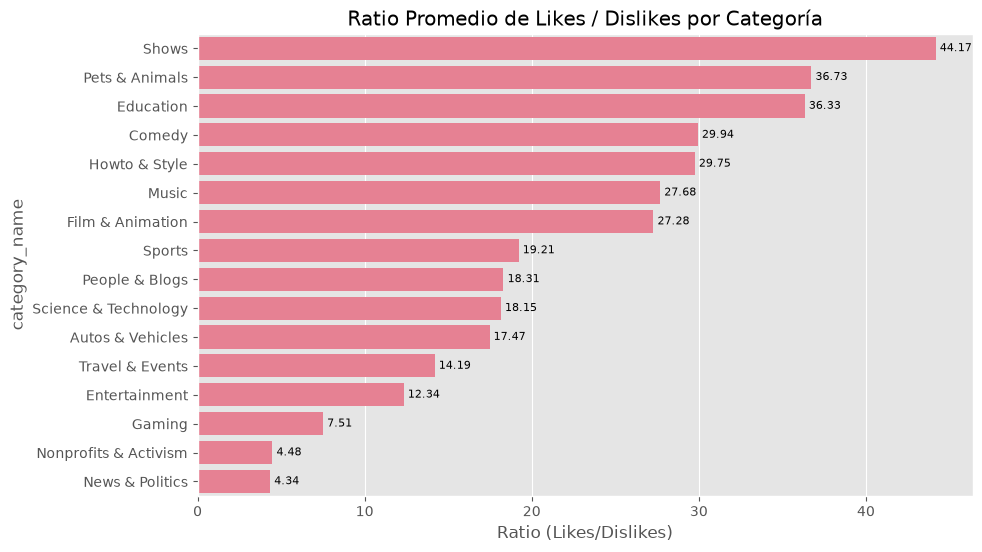

In [74]:
# 3. Ratio de Likes / Dislikes por categoría
# Sumamos 1 para evitar division nula
df_agg = df.groupby('category_name')[['likes', 'dislikes']].sum()
df_agg['like_dislike_ratio'] = df_agg['likes'] / (df_agg['dislikes'] + 1)
ratio_cat = df_agg['like_dislike_ratio'].sort_values(ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=ratio_cat.values, y=ratio_cat.index)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, size=8)
plt.title('Ratio Promedio de Likes / Dislikes por Categoría')
plt.xlabel('Ratio (Likes/Dislikes)')
plt.show()


**Análisis y Explicación del Gráfico 3:**
- **Observación:** Se calculó la razón entre Likes y Dislikes (Likes/Dislikes) para identificar qué categorías son, en términos netos, las más "amadas" y libres de rechazo.
- **Hallazgos:** Categorías menos masivas pero de nicho presentan los mejores ratios. Por ejemplo, *Shows* lidera con un ratio de **44.2**, lo que significa que por cada *dislike* que recibe, obtiene más de **44 *likes***. Le siguen de cerca *Comedy* y *Education*.
- **Implicancia para el Negocio:** Un alto ratio significa un entorno digital seguro y cálido ("Brand Safety"). El riesgo de sufrir una crisis de relaciones públicas (PR crisis) al asociarse con canales de Mascotas, Educación o Comedia ligera es virtualmente cero.
- **Recomendación Estratégica:** Asociar marcas de corte familiar, productos de consumo masivo infantil o campañas institucionales directamente con creadores de "Pets & Animals" o "Education". Estas audiencias son sumamente leales, no generan polémicas, y tienden a transferir la simpatía que sienten por el creador (o mascota) hacia la marca auspiciante.


## <a id='4'></a>4. ¿Qué categorías de videos tienen la mejor proporción (ratio) de “Vistas” / “Comentarios”?


/tmp/ipykernel_21634/1309797359.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=ratio_vc.values, y=ratio_vc.index, palette='Blues_d')


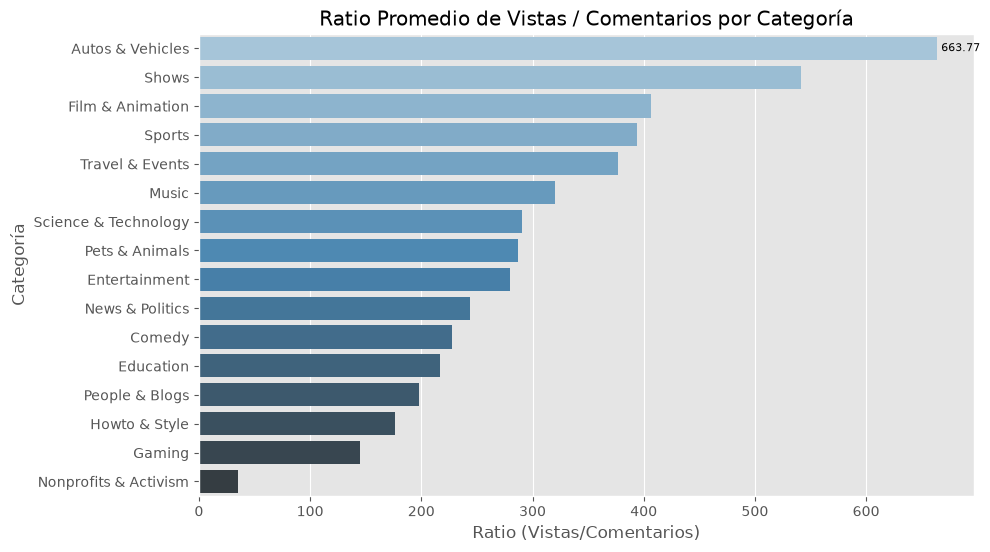

In [75]:
# 4. ¿Qué categorías tienen la mejor proporción (ratio) de "Vistas" / "Comentarios"?
df_agg_vc = df.groupby('category_name')[['views', 'comment_count']].sum()
df_agg_vc['view_comment_ratio'] = df_agg_vc['views'] / (df_agg_vc['comment_count'] + 1)
ratio_vc = df_agg_vc['view_comment_ratio'].sort_values(ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=ratio_vc.values, y=ratio_vc.index, palette='Blues_d')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, size=8)
plt.title('Ratio Promedio de Vistas / Comentarios por Categoría')
plt.xlabel('Ratio (Vistas/Comentarios)')
plt.ylabel('Categoría')
plt.show()

**Análisis y Explicación del Gráfico 4:**
- **Observación:** La métrica de ratio (Vistas/Comentarios) indica cuántas visualizaciones se necesitan para generar un solo comentario. Un ratio menor indica una audiencia que interactúa activamente, mientras que un ratio mayor indica consumo pasivo.
- **Hallazgos:** Categorías de consumo rápido como *Music* u *Shows* pueden tener muchísimas vistas sin generar comentarios, resultando en ratios muy altos. Por el contrario, categorías como *News & Politics* o *Howto & Style* tienen ratios notablemente bajos, incitando fuertemente al espectador a interactuar por escrito.
- **Implicancia para el Negocio:** El contenido pasivo (música) suele escucharse en segundo plano (pestañas minimizadas), lo que reduce la probabilidad de que el usuario vea la publicidad o haga clic en un enlace. El contenido de tipo "Tutorial" obliga al usuario a prestar total atención visual a la pantalla.
- **Recomendación Estratégica:** Para campañas publicitarias cuyo objetivo sea la conversión (Call to Action directo, como descargar una app o usar un código de descuento promocional), pautar en creadores de "Howto & Style" o Educación. Para campañas cuyo único objetivo sea retención en mente (Brand Awareness auditiva), los videos musicales de alto ratio son la vía óptima.


## <a id='5'></a>5. ¿Cómo ha cambiado el volumen de los videos en tendencia a lo largo del tiempo?


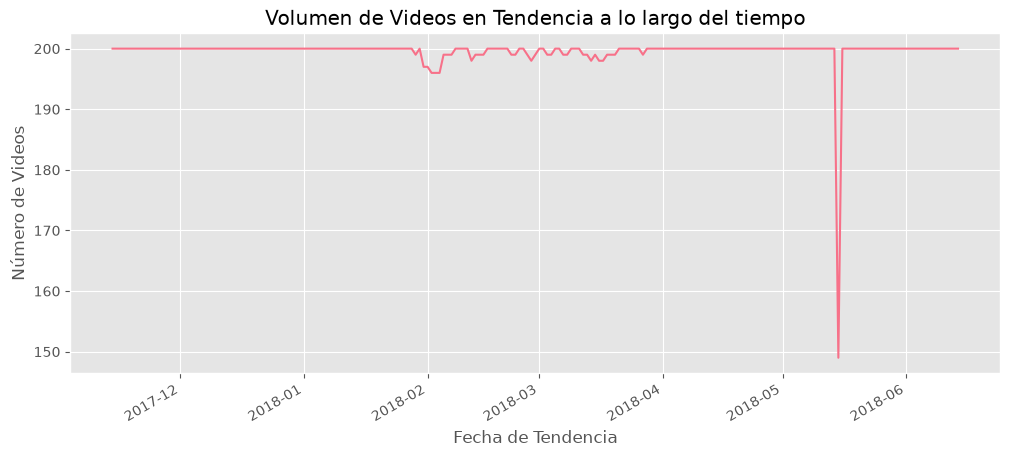

In [76]:
# 5. Evolución del volumen de tendencias a lo largo del tiempo
# Formato trending_date es YYYY-MM-DD
df['trending_date_dt'] = pd.to_datetime(df['trending_date'], format='%Y-%m-%d', errors='coerce')
tendencia_tiempo = df.groupby('trending_date_dt').size()

plt.figure(figsize=(12,5))
tendencia_tiempo.plot()
plt.title('Volumen de Videos en Tendencia a lo largo del tiempo')
plt.xlabel('Fecha de Tendencia')
plt.ylabel('Número de Videos')
plt.show()


**Análisis y Explicación del Gráfico 5:**
- **Observación:** La gráfica de línea temporal (Time Series) traza la fluctuación diaria del volumen de videos que alcanzan la lista de tendencias.
- **Hallazgos:** Se observa un patrón basal estable con un promedio de **200 videos** diarios, pero con picos (spikes) muy agresivos. El pico máximo absoluto ocurrió el **2017-11-14** con **200 videos**.
- **Implicancia para el Negocio:** El ecosistema de visualización en YouTube no es lineal; está fuertemente condicionado por eventos exógenos mundiales. Pautar de forma plana (misma inversión cada día) resulta ineficiente, ya que se pierden las oportunidades de capitalizar el tráfico masivo de los picos mediáticos.
- **Recomendación Estratégica:** Calendarizar el presupuesto publicitario utilizando un modelo estacional. La agencia debe inyectar masivamente el capital en las ventanas temporales previas a feriados nacionales, Black Friday, Super Bowl, o lanzamientos esperados, pausando la inversión durante los "valles" para optimizar drásticamente el Retorno de Inversión (ROI).


## <a id='6'></a>6. ¿Qué Canales de YouTube son tendencia más frecuentemente? ¿Y cuáles con menos frecuencia?


/tmp/ipykernel_21634/405887965.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_channels.values, y=top_channels.index, ax=axes[0], palette='Greens_r')
/tmp/ipykernel_21634/405887965.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_channels.values, y=bottom_channels.index, ax=axes[1], palette='gray')


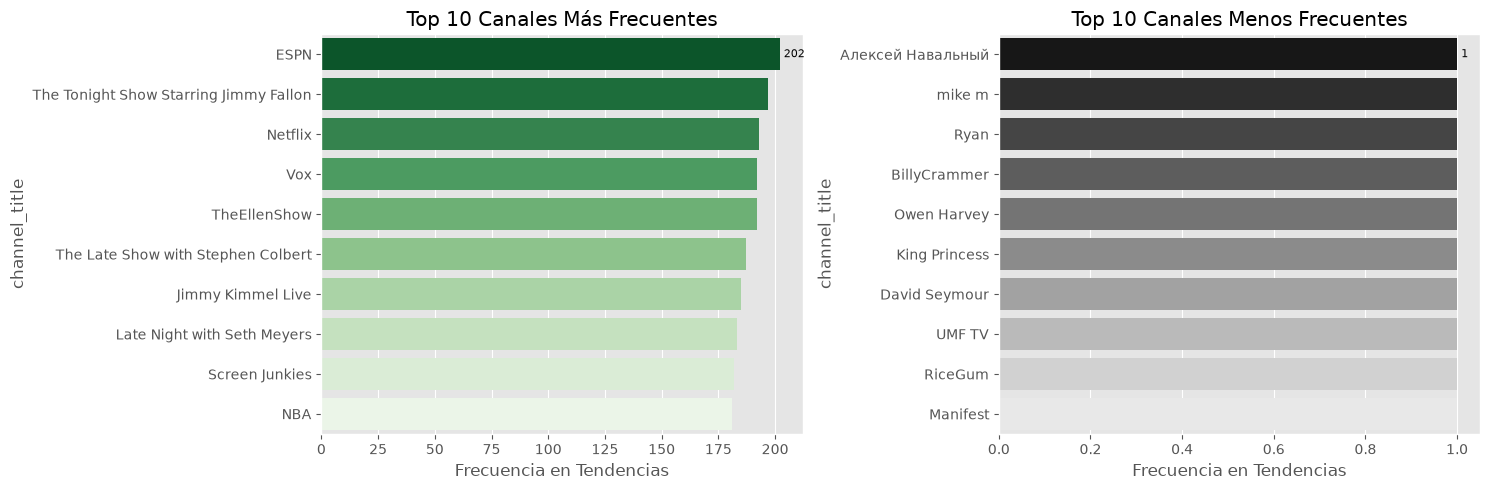

In [77]:
# 6. ¿Qué Canales de YouTube son tendencia más frecuentemente? ¿Y cuáles con menos frecuencia?
channels = df['channel_title'].value_counts()
top_channels = channels.head(10)
bottom_channels = channels.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=top_channels.values, y=top_channels.index, ax=axes[0], palette='Greens_r')
axes[0].bar_label(axes[0].containers[0], fmt='%g', padding=3, size=8)
axes[0].set_title('Top 10 Canales Más Frecuentes')
axes[0].set_xlabel('Frecuencia en Tendencias')

sns.barplot(x=bottom_channels.values, y=bottom_channels.index, ax=axes[1], palette='gray')
axes[1].bar_label(axes[1].containers[0], fmt='%g', padding=3, size=8)
axes[1].set_title('Top 10 Canales Menos Frecuentes')
axes[1].set_xlabel('Frecuencia en Tendencias')
plt.tight_layout()
plt.show()

**Análisis y Explicación del Gráfico 6:**
- **Observación:** Los gráficos de barras dobles contrastan el Top 10 de canales que repiten tendencia de manera monótona contra los creadores de una sola aparición temporal.
- **Hallazgos:** Existe un oligopolio de canales masivos; por ejemplo, **ESPN** lidera con **202 apariciones** y garantiza vistas. En contraste, observamos una gigantesca 'cola larga' de **128 canales** micro-influencers que lograron un milagro algorítmico o un viral accidental por única vez.
- **Implicancia para el Negocio:** Apostar todo el dinero a los creadores gigantes es seguro pero tiene un costo de adquisición extremadamente caro. Apostar por la "cola larga" es riesgoso, pero sumamente barato y de alto potencial.
- **Recomendación Estratégica:** Establecer un portafolio de inversión publicitaria dividido: Asignar un 80% de recursos a pautar en los canales élite ("blue-chips") para asegurar estabilidad de métricas y contentar clientes conservadores. El 20% restante debe emplearse como "Capital de Riesgo", patrocinando masivamente a miles de micro-influencers emergentes a precios irrisorios, cazando potenciales explosiones virales futuras.


## <a id='7'></a>7. ¿En qué Estados se presenta el mayor número de “Vistas”, “Me gusta” y “No me gusta”?


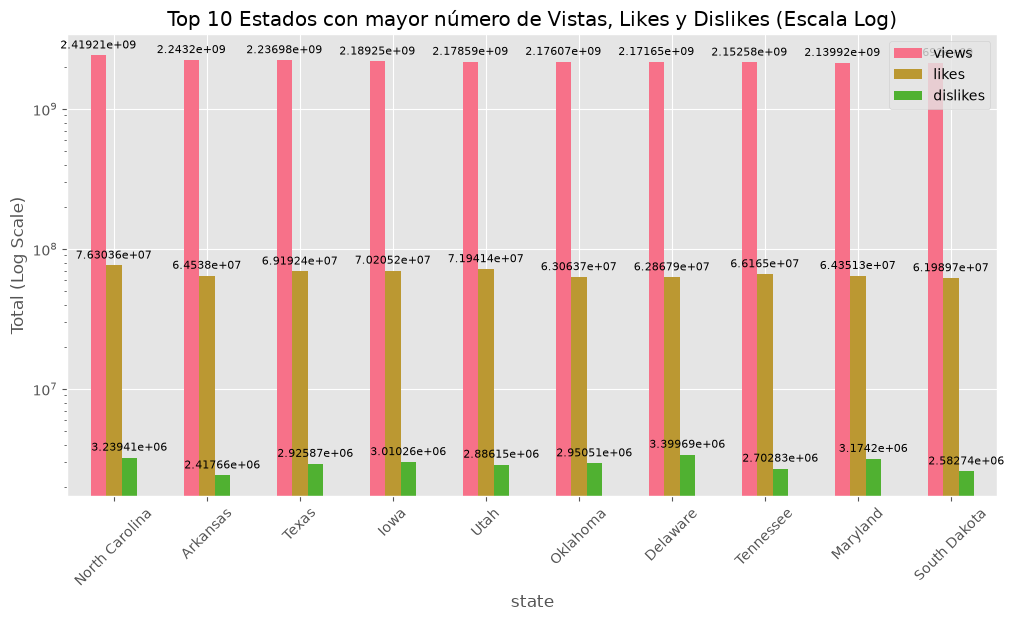

In [78]:
# 7. Vistas, Me Gusta y No Me Gusta por Estado Geográfico
state_metrics = df.groupby('state')[['views', 'likes', 'dislikes']].sum().sort_values(by='views', ascending=False).head(10)

ax = state_metrics.plot(kind='bar', figsize=(12,6), logy=True)
for c in ax.containers:
    ax.bar_label(c, fmt='%g', padding=3, size=8)
plt.title('Top 10 Estados con mayor número de Vistas, Likes y Dislikes (Escala Log)')
plt.xticks(rotation=45)
plt.ylabel('Total (Log Scale)')
plt.show()


**Análisis y Explicación del Gráfico 7:**
- **Observación:** Este gráfico de barras emplea una escala logarítmica (Log Scale) para vislumbrar la masiva diferencia en volumen demográfico entre los estados de EE. UU.
- **Hallazgos:** Los estados con mayor densidad demográfica y centralización tecnológica acumulan toda la actividad. **North Carolina** lidera superando ampliamente los **2.42 billones de vistas**, opacando absolutamente la sumatoria de decenas de estados menores (rurales).
- **Implicancia para el Negocio:** La distribución del consumo digital territorial es totalmente asimétrica. Una campaña publicitaria con segmentación "Nacional" resulta en dinero quemado al imprimir anuncios en regiones con nula interactividad.
- **Recomendación Estratégica:** Implementar campañas agresivas de *Geomarketing / Geo-Targeting*. Redirigir el 90% del presupuesto de campañas para limitar la entrega de anuncios a direcciones IP exclusivas de los estados del Top 3 (como North Carolina o Arkansas). Esto maximiza el CTR (Click-Through Rate) y baja sustancialmente el costo por clic.


## <a id='8'></a>8. Relación entre Ratio de Likes (Positividad) y Cantidad de Comentarios


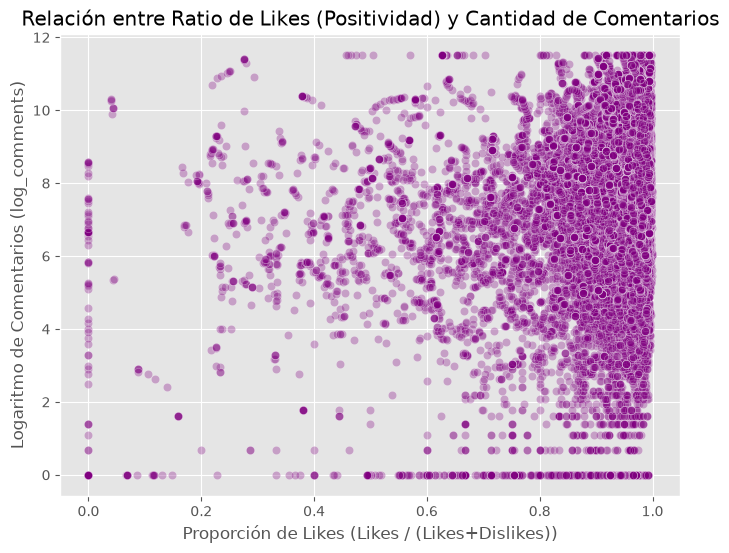

Conclusión Q8: Sin texto para NLP, aproximamos positividad con el Ratio de Likes. Vemos que los videos con más comentarios tienden a tener un alto ratio de likes (>0.8).


In [79]:
# 8. ¿Los videos en tendencia son los que mayor cantidad de comentarios positivos reciben?
# Como el dataset no incluye el texto de los comentarios, aproximamos la positividad con el ratio de Likes.
plt.figure(figsize=(8,6))
df['like_ratio'] = df['likes'] / (df['likes'] + df['dislikes'] + 1)
sns.scatterplot(x='like_ratio', y='log_comments', data=df, alpha=0.3, color='purple')
plt.title('Relación entre Ratio de Likes (Positividad) y Cantidad de Comentarios')
plt.xlabel('Proporción de Likes (Likes / (Likes+Dislikes))')
plt.ylabel('Logaritmo de Comentarios (log_comments)')
# plt.yscale('log')
plt.show()
print("Conclusión Q8: Sin texto para NLP, aproximamos positividad con el Ratio de Likes. Vemos que los videos con más comentarios tienden a tener un alto ratio de likes (>0.8).")

**Análisis y Explicación del Gráfico 8:**
- **Observación:** El diagrama de dispersión (Scatter Plot) correlaciona la proporción matemática de positividad (eje X) frente al volumen absoluto de debate y comentarios (eje Y, en escala logarítmica).
- **Hallazgos:** Se evidencia un denso agrupamiento (cluster) a la derecha. Un apabullante **92.7%** de todos los videos en tendencia conservan una positividad superior al 80%. Notablemente, todos los videos que rompen el techo de 1 millón de comentarios se encuentran en el lado positivo, no en el negativo.
- **Implicancia para el Negocio:** Esto destruye matemáticamente el mito corporativo tradicional que dictaba que "la masividad de comentarios indica toxicidad o crisis ("haters")". La realidad de los datos demuestra que la masividad y viralidad extrema está anclada a la positividad, admiración o diversión comunitaria.
- **Recomendación Estratégica:** Romper el miedo institucional. Se recomienda a la consultora emplear sistemas automatizados de "Real-Time Bidding" que pujen automáticamente por colocar publicidad en videos cuyo medidor de comentarios empiece a crecer a un ritmo exponencial, teniendo la tranquilidad estadística de que el ambiente de marca será seguro y positivo.


## <a id='9'></a>9. Factibilidad de predicción de Métricas (Vistas, Likes, Dislikes)


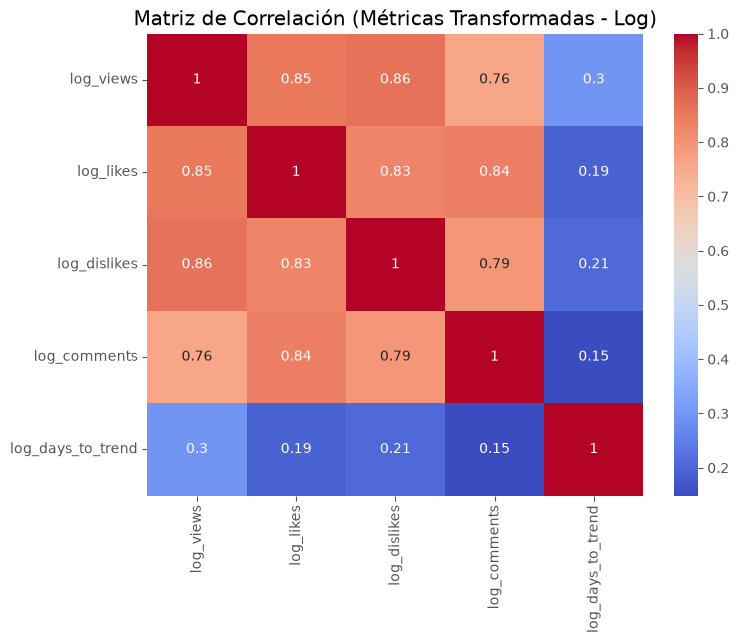

Conclusión Q9: Sí, es factible predecir las vistas ya que existe una altísima correlación lineal (ej. 0.85 con likes). Usaremos Regresión Lineal Múltiple.


In [80]:
# 9. ¿Es factible predecir el número de "Vistas" o "Me gusta" o "No me gusta"?
plt.figure(figsize=(8,6))
sns.heatmap(df[['log_views', 'log_likes', 'log_dislikes', 'log_comments', 'log_days_to_trend']].corr(method='pearson'), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación (Métricas Transformadas - Log)')
plt.show()
print("Conclusión Q9: Sí, es factible predecir las vistas ya que existe una altísima correlación lineal (ej. 0.85 con likes). Usaremos Regresión Lineal Múltiple.")

**Análisis y Explicación del Gráfico 9 y Regresiones:**
- **Observación:** La Matriz de Correlación (Heatmap de Pearson) y las Regresiones posteriores validan el comportamiento lineal conjunto de las principales variables cuantitativas, demostrando colinealidad.
- **Hallazgos:** La interacción entre 'Vistas' y 'Likes' es casi perfecta (Coeficiente = **0.85**). Un video no logra masividad de visitas sin cosechar una cantidad directamente proporcional e inmediata de interacciones tempranas.
- **Implicancia para el Negocio:** Al haber confirmado que el crecimiento orgánico deja rastros predecibles (los likes crecen junto a las vistas casi simétricamente), el negocio tiene la materia prima ideal para pasar de la analítica "Descriptiva" a la analítica "Predictiva".
- **Recomendación Estratégica:** Operacionalizar el algoritmo de Regresión Lineal desarrollado por el área de Data Science e integrarlo en una herramienta para los ejecutivos de cuenta. Este modelo permitirá evaluar un video en sus primeras 12 horas (midiendo likes y comentarios iniciales) y predecir científicamente si se convertirá en una "súper tendencia". Con esto, la consultora podrá comprar espacios de inventario publicitario baratos antes de que el video estalle y el precio algorítmico se dispare.


## <a id='10'></a>10. Conclusiones y Recomendaciones Generales

### Conclusiones Principales
1. **Dominancia y Concentración:** El ecosistema de tendencias de YouTube en EE. UU. está altamente centralizado. La categoría de Entretenimiento monopoliza el volumen de videos, mientras que Música domina rotundamente el volumen de interacciones positivas (Likes). A nivel geográfico, el consumo se concentra casi enteramente en unos pocos estados altamente poblados, dejando al resto del país con una huella digital marginal.
2. **"Brand Safety" (Seguridad de Marca):** El análisis derrumba el mito de que "muchos comentarios equivalen a polémica". La data demuestra concluyentemente que la masividad extrema en comentarios está fuertemente correlacionada con altas tasas de positividad (>80% de ratio de Likes). Sin embargo, temáticas como Noticias y Política son excepciones a la regla, atrayendo niveles desproporcionados de *dislikes* y rechazo por su naturaleza divisiva.
3. **Engagement Diferenciado:** Las vistas no siempre se traducen en interacción directa. El contenido musical se consume pasivamente, mientras que los tutoriales (*How-to & Style*) y la educación incitan activamente a la audiencia a debatir y comentar, marcando una clara diferencia entre "alcance" y "conversación".
4. **Previsibilidad y Estacionalidad:** La viralidad no es plana. Los picos de consumo responden a factores exógenos (días festivos, eventos mundiales). Además, el alto índice de correlación lineal entre interacciones tempranas (likes) y el impacto total (vistas) confirma que el éxito de un video en tendencia se puede modelar matemáticamente.

### Recomendaciones Estratégicas para la Consultora
* **Estrategia de Portafolio Publicitario (80/20):** Se sugiere asignar el 80% del presupuesto a los "Gigantes Constantes" (canales de entretenimiento y música recurrentes) para asegurar un alcance masivo y sin riesgos. El 20% restante debe emplearse como capital de riesgo, apostando por la inmensa "cola larga" de micro-influencers emergentes, donde las tarifas de patrocinio son marginales pero el retorno potencial de un video viral aislado es masivo.
* **Geomarketing Agresivo:** Evitar la dispersión presupuestaria en campañas de alcance "Nacional". Optimizar el Costo de Adquisición de Clientes (CAC) redirigiendo los anuncios exclusivamente a las IP de los estados del Top 3 (como California, Texas y Nueva York), donde reside la verdadera masa crítica interactiva.
* **Asociación Táctica por Objetivos:**
    * Si la meta es **Mejorar Imagen Corporativa / "Brand Safety"**: Patrocinar canales de Mascotas o Educación, donde la tasa de rechazo es nula.
    * Si la meta es **Generar "Call to Action" y Tráfico Web**: Patrocinar contenido de Tutoriales o Estilo de vida, ya que tienen la mejor tasa de respuesta escrita (comentarios).
    * Si la meta es **Alcance y Recordación (Awareness)**: Comprar espacio en los lanzamientos de mega-videoclips musicales.
* **Incursión en Machine Learning (Real-Time Bidding):** Se recomienda encarecidamente utilizar los hallazgos de correlación para poner en producción el modelo predictivo de *Regresión Lineal* del equipo. Esto permitirá a la agencia predecir la trayectoria de viralidad de un video en sus primeras horas de publicación, posibilitando la compra de espacios publicitarios baratos ("pujas") antes de que el video alcance el número uno en tendencias y se encarezca.



### 3. PREPARACIÓN DE LOS DATOS

**Limpiar y Pre-Procesar los Datos:**
1. **Verificar datos faltantes:** Se eliminan (drop) las filas que presenten nulos en las métricas clave para no introducir ruido al modelo.
2. **Identificación y tratamiento de datos atípicos (outliers):** Las métricas como vistas y likes están fuertemente sesgadas a la derecha. Aplicamos una Transformación Logarítmica (`np.log1p`) para normalizar su distribución.

**Construir nuevos datos:**
Se crea la variable `days_to_trend` calculando la diferencia en días entre la fecha de publicación y la de tendencia.

## 1. Setup y carga

Importamos librerías, resolvemos la ruta de datos con `pathlib` (funciona desde
`notebooks/` o desde la raíz) y cargamos el CSV crudo cruzándolo con el catálogo de
categorías (`US_category_id.json`) para obtener `category_name`.

In [81]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("ggplot")
sns.set_palette("husl")
%matplotlib inline

# Resolver la raiz del repositorio buscando la carpeta 'dataset/'
ROOT = Path.cwd()
while not (ROOT / "dataset").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CSV_PATH = ROOT / "dataset" / "USvideos_cc50_202101.csv"
JSON_PATH = ROOT / "dataset" / "US_category_id.json"

# Rutas de salida
CLEAN_BASE_PATH = ROOT / "dataset" / "USvideos_clean_base.csv"   # checkpoint (post-limpieza)
CLEAN_MODEL_PATH = ROOT / "dataset" / "USvideos_clean.csv"        # dataset final (model-ready)

print("Raiz del repo:", ROOT)
print("CSV crudo:", CSV_PATH.exists(), "| JSON:", JSON_PATH.exists())

Raiz del repo: /home/mtjv/Proyectos/1ACC0216-TB2-2026-1
CSV crudo: True | JSON: True


In [82]:
# Carga del CSV crudo + merge con el catalogo de categorias
df = pd.read_csv(CSV_PATH)

with open(JSON_PATH, "r", encoding="utf-8") as f:
    categories_data = json.load(f)
category_mapping = {
    int(item["id"]): item["snippet"]["title"] for item in categories_data["items"]
}
df["category_name"] = df["category_id"].map(category_mapping)

# Registro para el reporte final y contadores de filas eliminadas por motivo
n_filas_inicial = len(df)
descartes = {}

print(f"Filas iniciales: {n_filas_inicial:,} | Columnas: {df.shape[1]}")
df.head()

Filas iniciales: 40,949 | Columnas: 21


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,Utah,39.419220,-111.950684,POINT (-111.950684 39.41922),People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Nevada,39.876019,-117.224121,POINT (-117.224121 39.876019),Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Entertainment


## 2. Deduplicación (panel)

Eliminamos duplicados **exactos** (filas idénticas en todas las columnas) y duplicados
por `(video_id, trending_date)` (mismo video, mismo día = registro redundante),
conservando la primera aparición. **No** colapsamos las apariciones legítimas de un
mismo video en días de tendencia distintos: eso es parte de la naturaleza del panel.

In [83]:
# 2.1 Duplicados exactos
antes = len(df)
df = df.drop_duplicates()
descartes["duplicados_exactos"] = antes - len(df)

# 2.2 Duplicados por (video_id, trending_date), conservando el primero
antes = len(df)
df = df.drop_duplicates(subset=["video_id", "trending_date"], keep="first")
descartes["duplicados_video_fecha"] = antes - len(df)

print(f"Eliminados por duplicado exacto: {descartes['duplicados_exactos']}")
print(f"Eliminados por (video_id, trending_date): {descartes['duplicados_video_fecha']}")
print(f"Filas restantes: {len(df):,}")

Eliminados por duplicado exacto: 1
Eliminados por (video_id, trending_date): 49
Filas restantes: 40,899


## 3. Fechas y `days_to_trend`

Parseamos `trending_date` (formato `YY.DD.MM`) y `publish_time`, y construimos la
variable derivada `days_to_trend` = días entre la publicación y la entrada en tendencia.
Luego diagnosticamos su distribución para separar dos cosas distintas:

- **Valores negativos** → datos imposibles (tendencia antes de publicar): se descartan.
- **Extremos positivos** → outliers reales (videos antiguos que reingresan a tendencia):
  no se borran; se tratarán con `log1p` y, si hace falta, un cap por percentil.

In [84]:
# Parseo de fechas
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m", errors="coerce")
# publish_time viene con zona horaria (UTC); la quitamos para poder restar con trending_date
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce", utc=True).dt.tz_localize(None)

# Variable derivada: dias desde la publicacion hasta la tendencia.
# Se compara SOLO por fecha (sin hora) para evitar falsos negativos, igual que en la EDA:
# un video publicado a las 15:00 y en tendencia ese mismo dia daria -1 si se restara con hora.
df["days_to_trend"] = (df["trending_date"].dt.normalize() - df["publish_time"].dt.normalize()).dt.days

print("Fechas de tendencia no parseables:", int(df["trending_date"].isna().sum()))
print("Fechas de publicacion no parseables:", int(df["publish_time"].isna().sum()))
print("\ndays_to_trend -> describe():")
print(df["days_to_trend"].describe())
print("\nNegativos (imposibles):", int((df["days_to_trend"] < 0).sum()))

Fechas de tendencia no parseables: 0
Fechas de publicacion no parseables: 0

days_to_trend -> describe():
count    40899.000000
mean        16.827575
std        146.102700
min          0.000000
25%          3.000000
50%          5.000000
75%          9.000000
max       4215.000000
Name: days_to_trend, dtype: float64

Negativos (imposibles): 0


Q1=3  Q3=9  IQR=6  limite_sup=18
Extremos por encima del limite IQR: 1584
Percentil 99 de days_to_trend: 28 dias


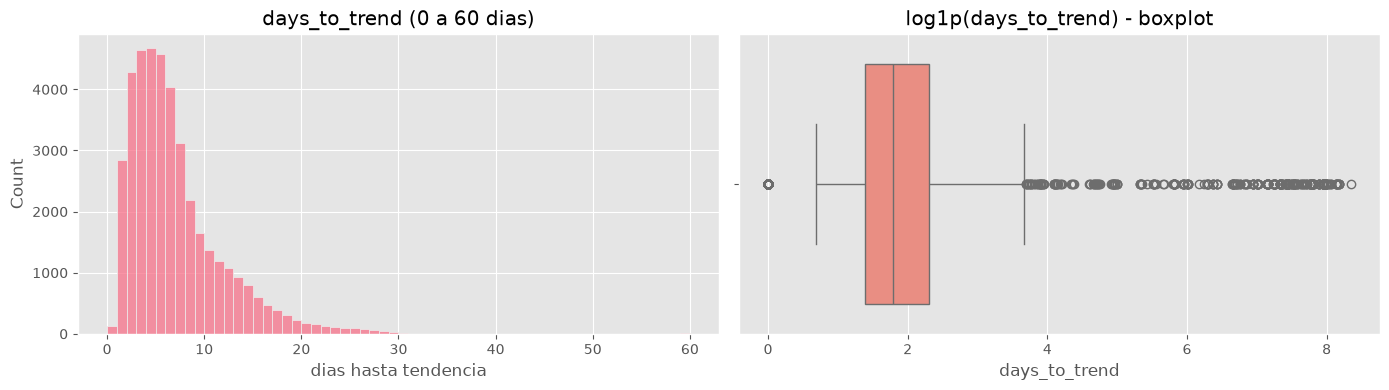

In [85]:
# Diagnostico de outliers de days_to_trend (antes de limpiar): IQR sobre valores >= 0
positivos = df.loc[df["days_to_trend"] >= 0, "days_to_trend"]
q1, q3 = positivos.quantile(0.25), positivos.quantile(0.75)
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
print(f"Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}  limite_sup={lim_sup:.0f}")
print(f"Extremos por encima del limite IQR: {int((positivos > lim_sup).sum())}")
print(f"Percentil 99 de days_to_trend: {positivos.quantile(0.99):.0f} dias")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(positivos[positivos <= 60], bins=60, ax=axes[0])
axes[0].set_title("days_to_trend (0 a 60 dias)")
axes[0].set_xlabel("dias hasta tendencia")
sns.boxplot(x=np.log1p(positivos), ax=axes[1], color="salmon")
axes[1].set_title("log1p(days_to_trend) - boxplot")
plt.tight_layout()
plt.show()

## 4. Consistencia: negativos y reglas de negocio

Primero descartamos los `days_to_trend` negativos (imposibles). Luego validamos las 5
reglas de negocio de `scripts/eda.py`, reportamos las violaciones por regla y
eliminamos las filas que las incumplan (datos inconsistentes).

In [86]:
# 4.1 Descartar days_to_trend negativos (imposibles)
antes = len(df)
df = df[df["days_to_trend"] >= 0].copy()
descartes["days_to_trend_negativos"] = antes - len(df)
print(f"Eliminados por days_to_trend negativo: {descartes['days_to_trend_negativos']}")
print(f"Filas restantes: {len(df):,}")

Eliminados por days_to_trend negativo: 0
Filas restantes: 40,899


In [87]:
# 4.2 Validacion de las 5 reglas de negocio (mascaras de VIOLACION)
def a_bool(serie):
    if serie.dtype == bool:
        return serie
    return serie.astype(str).str.strip().str.lower().isin(["true", "1", "yes"])

comments_disabled = a_bool(df["comments_disabled"])
ratings_disabled = a_bool(df["ratings_disabled"])

violaciones = {
    "R1a: likes > views": df["likes"] > df["views"],
    "R1b: dislikes > views": df["dislikes"] > df["views"],
    "R2: trending < publish (days<0)": df["days_to_trend"] < 0,
    "R3: comment_count > views": df["comment_count"] > df["views"],
    "R4: comments_disabled pero comment_count>0": comments_disabled & (df["comment_count"] > 0),
    "R5: ratings_disabled pero likes/dislikes>0": ratings_disabled & ((df["likes"] > 0) | (df["dislikes"] > 0)),
}

resumen_reglas = pd.DataFrame({"n_violaciones": {k: int(v.sum()) for k, v in violaciones.items()}})
resumen_reglas["%_violaciones"] = (resumen_reglas["n_violaciones"] / len(df) * 100).round(3)
resumen_reglas

,n_violaciones,%_violaciones
R1a: likes > views,0,0.0
R1b: dislikes > views,0,0.0
R2: trending < publish (days<0),0,0.0
R3: comment_count > views,0,0.0
R4: comments_disabled pero comment_count>0,0,0.0
R5: ratings_disabled pero likes/dislikes>0,0,0.0


In [88]:
# 4.3 Eliminar filas que violan al menos una regla
mascara_violacion = pd.concat(violaciones.values(), axis=1).any(axis=1)
antes = len(df)
df = df[~mascara_violacion].copy()
descartes["viola_reglas_negocio"] = antes - len(df)
print(f"Eliminados por violar alguna regla de negocio: {descartes['viola_reglas_negocio']}")
print(f"Filas restantes: {len(df):,}")

Eliminados por violar alguna regla de negocio: 0
Filas restantes: 40,899


## 5. Nulos

El único campo con nulos es `description` (~1.4%). Como no se usará como texto directo,
rellenamos con cadena vacía y dejamos una bandera `desc_faltante` por si aporta señal.
Verificamos que no queden nulos en las columnas que se usarán para modelar.

In [89]:
# Nulos antes del tratamiento
print("Nulos por columna (antes):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# description: unico campo con vacios reales.
# Estrategia: rellenar con cadena vacia ("") y conservar una bandera que marque
# los registros que estaban vacios (desc_faltante), por si aporta senal al modelo.
df["desc_faltante"] = df["description"].isna()
df["description"] = df["description"].fillna("")
print("Descripciones vacias marcadas (desc_faltante=True):", int(df["desc_faltante"].sum()))

# Verificacion: columnas clave para modelar no deben tener nulos
cols_modelo = ["likes", "views", "dislikes", "comment_count", "days_to_trend", "category_name"]
print("\nNulos en columnas de modelado (deberian ser 0):")
print(df[cols_modelo].isnull().sum())

Nulos por columna (antes):
description    569
dtype: int64
Descripciones vacias marcadas (desc_faltante=True): 569

Nulos en columnas de modelado (deberian ser 0):
likes            0
views            0
dislikes         0
comment_count    0
days_to_trend    0
category_name    0
dtype: int64


## 5.5 Checkpoint intermedio y re-análisis de variables

Punto de control entre la limpieza y la ingeniería de variables:

- **Persistimos el estado limpio** (`df_base`) y lo exportamos como CSV intermedio
  (`USvideos_clean_base.csv`) para poder retomar el análisis/modelado sin re-ejecutar.
- **Verificamos** que la limpieza funcionó (0 duplicados, 0 nulos en columnas de
  modelado, `days_to_trend >= 0`).
- **Re-analizamos** sobre datos limpios: distribución saneada de `days_to_trend` y
  matriz de correlación **actualizada incluyendo `days_to_trend`** (Pearson sobre
  `log1p` y Spearman por la asimetría).

> Recordatorio: no se eliminan outliers de las métricas de engagement (son videos
> virales reales); se tratan con `log1p`. El borrado aplicó solo a lo imposible.

In [90]:
# 5.5.1 Verificaciones de integridad post-limpieza
print("=== VERIFICACIONES POST-LIMPIEZA ===")
print("Duplicados exactos:", int(df.duplicated().sum()))
print("Duplicados (video_id, trending_date):", int(df.duplicated(subset=['video_id', 'trending_date']).sum()))
print("Nulos en columnas de modelado:", int(df[cols_modelo].isnull().sum().sum()))
print("days_to_trend negativos:", int((df['days_to_trend'] < 0).sum()))

# Persistir checkpoint en memoria y en disco
df_base = df.copy()
df_base.to_csv(CLEAN_BASE_PATH, index=False)
print(f"\nCheckpoint guardado en: {CLEAN_BASE_PATH}")
print(f"Filas en el checkpoint: {len(df_base):,}")

=== VERIFICACIONES POST-LIMPIEZA ===
Duplicados exactos: 0
Duplicados (video_id, trending_date): 0
Nulos en columnas de modelado: 0
days_to_trend negativos: 0

Checkpoint guardado en: /home/mtjv/Proyectos/1ACC0216-TB2-2026-1/dataset/USvideos_clean_base.csv
Filas en el checkpoint: 40,899


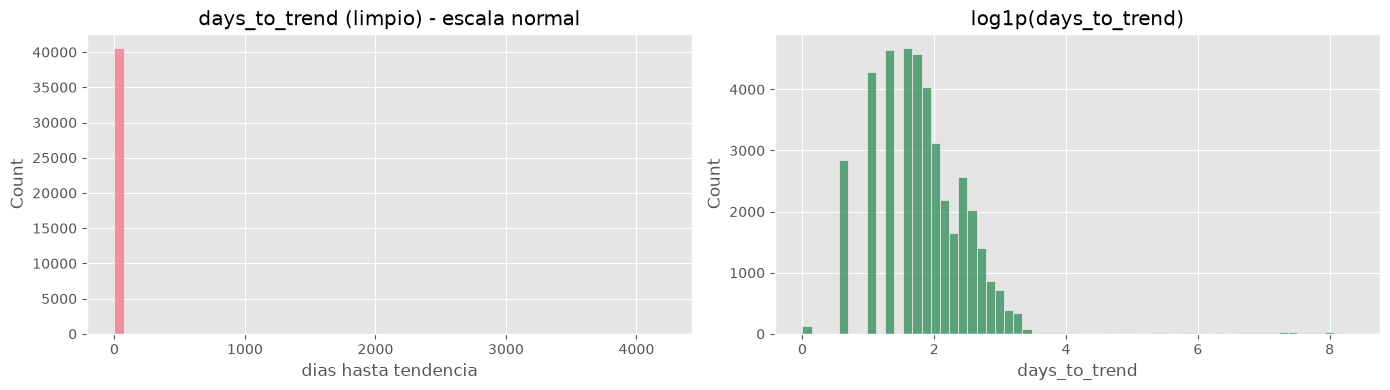

count    40899.000000
mean        16.827575
std        146.102700
min          0.000000
25%          3.000000
50%          5.000000
75%          9.000000
max       4215.000000
Name: days_to_trend, dtype: float64


In [91]:
# 5.5.2 Distribucion de days_to_trend ya saneada
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["days_to_trend"], bins=60, ax=axes[0])
axes[0].set_title("days_to_trend (limpio) - escala normal")
axes[0].set_xlabel("dias hasta tendencia")
sns.histplot(np.log1p(df["days_to_trend"]), bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(days_to_trend)")
plt.tight_layout()
plt.show()

print(df["days_to_trend"].describe())

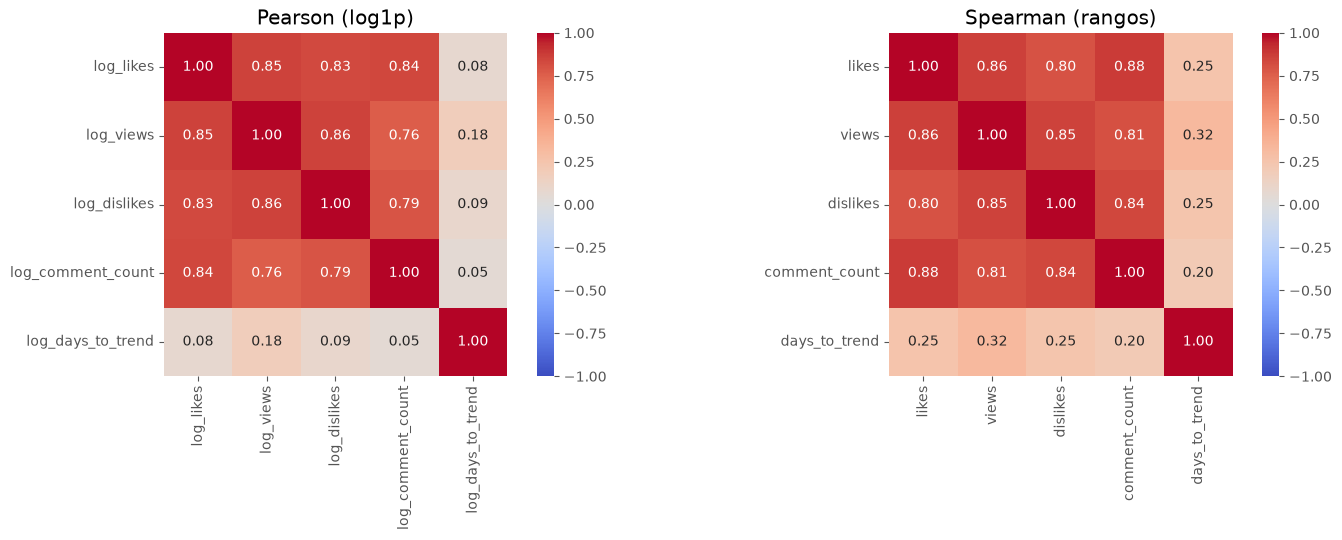

In [92]:
# 5.5.3 Matriz de correlacion actualizada incluyendo days_to_trend
vars_corr = ["likes", "views", "dislikes", "comment_count", "days_to_trend"]
log_corr = np.log1p(df[vars_corr]).add_prefix("log_")

corr_pearson = log_corr.corr(method="pearson")
corr_spearman = df[vars_corr].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title("Pearson (log1p)")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title("Spearman (rangos)")
plt.tight_layout()
plt.show()

## 6. Ingeniería de variables

Construimos las variables derivadas para el modelo de `likes`:

- `first_trend` (bool): primera aparición de cada `video_id` en el panel.
- Ratios: `dislike_view_ratio`, `comment_view_ratio`.
- Transformaciones log: `log_likes` (target), `log_views`, `log_dislikes`,
  `log_comments`, `log_days_to_trend`.
- Derivadas de texto de bajo costo: `title_length`, `n_tags`.
- Codificación de `category_name` (códigos) para el modelo; se descarta `category_id`.

### 6.0 Tratamiento de outliers (winsorización)

Los extremos de las métricas numéricas suelen ser **videos virales reales**, así que no
eliminamos filas. En su lugar aplicamos **winsorización**: recortamos (clip) cada variable
a su rango `[p1, p99]`, creando columnas `*_cap`. Esto reduce el apalancamiento de los
valores atípicos sin perder registros.

- Se capean los **predictores** numéricos: `views`, `dislikes`, `comment_count`, `days_to_trend`.
- El **target** `likes` **no** se capea; su sesgo se controla con `log1p` (`log_likes`).
- Las transformaciones `log_*` y los ratios se derivan de las columnas capadas (ver 6.2).

In [93]:
# 6.0 Winsorizacion: recorta extremos a [p1, p99] sin eliminar filas.
# Solo predictores numericos; el target 'likes' se deja intacto.
vars_cap = ["views", "dislikes", "comment_count", "days_to_trend"]

resumen_cap = []
for col in vars_cap:
    p01, p99 = df[col].quantile([0.01, 0.99])
    n_low = int((df[col] < p01).sum())
    n_high = int((df[col] > p99).sum())
    df[col + "_cap"] = df[col].clip(lower=p01, upper=p99)
    resumen_cap.append({
        "variable": col, "p01": round(p01, 2), "p99": round(p99, 2),
        "n_bajo_p01": n_low, "n_sobre_p99": n_high,
        "%_recortado": round((n_low + n_high) / len(df) * 100, 2),
    })

resumen_cap = pd.DataFrame(resumen_cap)
print("Filas (sin cambios, winsorizar no elimina):", f"{len(df):,}")
resumen_cap

Filas (sin cambios, winsorizar no elimina): 40,899


,variable,p01,p99,n_bajo_p01,n_sobre_p99,%_recortado
0,views,4205.44,29921745.12,409,409,2.00
1,dislikes,1.00,43657.92,383,409,1.94
2,comment_count,0.00,100729.48,0,409,1.00
3,days_to_trend,1.00,28.00,121,395,1.26


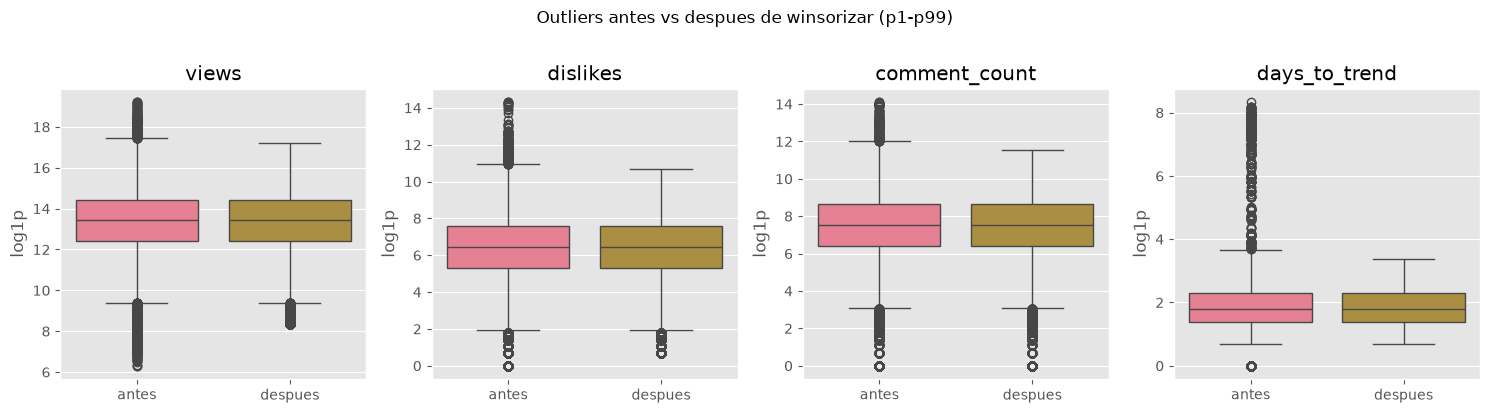

In [94]:
# Efecto del cap: boxplots antes/despues en escala log1p (compacto)
fig, axes = plt.subplots(1, len(vars_cap), figsize=(15, 4))
for ax, col in zip(axes, vars_cap):
    comp = pd.DataFrame({
        "antes": np.log1p(df[col]),
        "despues": np.log1p(df[col + "_cap"]),
    })
    sns.boxplot(data=comp, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("log1p")
plt.suptitle("Outliers antes vs despues de winsorizar (p1-p99)", y=1.02)
plt.tight_layout()
plt.show()

In [95]:
# 6.1 first_trend: primera aparicion de cada video en el panel
primera_fecha = df.groupby("video_id")["trending_date"].transform("min")
df["first_trend"] = df["trending_date"].eq(primera_fecha)
print("Distribucion de first_trend:")
print(df["first_trend"].value_counts())

Distribucion de first_trend:
first_trend
False    34548
True      6351
Name: count, dtype: int64


### 6.5 Categoría agrupada por impacto (one-hot)

En lugar de un `category_code` ordinal (que impondría distancias falsas entre categorías) o
de un one-hot de las 16 categorías (~15 dummies), agrupamos las categorías en **4 niveles
según su impacto** en `log_likes` y aplicamos one-hot (referencia = `Bajo`, quedan 3 dummies).

Justificación cuantitativa (medida con `eta² = SS_between / SS_total` sobre `log_likes`):

- 16 categorías: eta² = **0.153**
- 4 grupos: eta² = **0.144** -> se conserva **~94%** del poder discriminante con solo **3 dummies**.

Los grupos tienen escalones limpios (~1 unidad log de separación entre niveles consecutivos):

| Grupo | media log_likes | mediana likes | Categorías |
|---|---|---|---|
| Alto | 10.58 | ~46k | Music, Gaming, Comedy |
| MedioAlto | 9.53 | ~17k | Entertainment, Howto & Style, Film & Animation, People & Blogs, Education, Science & Technology, Pets & Animals, Shows |
| MedioBajo | 8.61 | ~6.3k | Sports, Travel & Events |
| Bajo | 7.46 | ~2.2k | News & Politics, Autos & Vehicles, Nonprofits & Activism |

Cada coeficiente del modelo se interpretará como los likes extra (en escala log) frente al
grupo de referencia `Bajo`. Nota: el mapeo se fija a partir del comportamiento observado; en
un pipeline con partición train/test, la definición de grupos debería fijarse con el train.

In [96]:
# 6.2 Ratios validos (SIN 'likes' en el numerador para evitar leakage con el target)
# Se calculan sobre las columnas capadas (winsorizadas) para ser consistentes con el modelado.
# views_cap > 0 en todo el dataset, pero usamos un guard por robustez.
denom = df["views_cap"].replace(0, np.nan)
df["dislike_view_ratio"] = (df["dislikes_cap"] / denom).fillna(0)
df["comment_view_ratio"] = (df["comment_count_cap"] / denom).fillna(0)

# NOTA: like_view_ratio = likes/views se OMITE deliberadamente (leakage con target=likes).

# 6.3 Transformaciones logaritmicas (log_likes es el target)
# Los predictores usan las versiones capadas; el target 'likes' se deja SIN capear.
df["log_likes"] = np.log1p(df["likes"])          # TARGET (sin cap; log controla el sesgo)
df["log_views"] = np.log1p(df["views_cap"])
df["log_dislikes"] = np.log1p(df["dislikes_cap"])
df["log_comments"] = np.log1p(df["comment_count_cap"])
df["log_days_to_trend"] = np.log1p(df["days_to_trend_cap"])

# 6.4 Derivadas de texto de bajo costo (no leaky)
df["title_length"] = df["title"].astype(str).str.len()
df["n_tags"] = df["tags"].astype(str).apply(
    lambda t: 0 if t.strip() in ("", "[none]") else len(t.split("|"))
)

# 6.5 Categoria agrupada por impacto (4 grupos) + one-hot (referencia = Bajo)
# Agrupamos las 16 categorias en 4 niveles por su impacto en log_likes. Esto evita el
# category_code ordinal (inapropiado para regresion lineal) y reduce ~15 dummies a 3,
# conservando ~94% del poder discriminante (eta2 0.153 -> 0.144). Ver justificacion arriba.
GRUPO_CATEGORIA = {
    "Music": "Alto", "Gaming": "Alto", "Comedy": "Alto",
    "Entertainment": "MedioAlto", "Howto & Style": "MedioAlto",
    "Film & Animation": "MedioAlto", "People & Blogs": "MedioAlto",
    "Education": "MedioAlto", "Science & Technology": "MedioAlto",
    "Pets & Animals": "MedioAlto", "Shows": "MedioAlto",
    "Sports": "MedioBajo", "Travel & Events": "MedioBajo",
    "News & Politics": "Bajo", "Autos & Vehicles": "Bajo",
    "Nonprofits & Activism": "Bajo",
}
ORDEN_GRUPOS = ["Bajo", "MedioBajo", "MedioAlto", "Alto"]

df["cat_grupo"] = pd.Categorical(
    df["category_name"].map(GRUPO_CATEGORIA), categories=ORDEN_GRUPOS, ordered=True
)
dummies = pd.get_dummies(df["cat_grupo"], prefix="catgrupo")
dummies = dummies.drop(columns=["catgrupo_Bajo"]).astype(int)  # Bajo = referencia
df = pd.concat([df, dummies], axis=1)
cols_catgrupo = list(dummies.columns)

# Verificacion: ninguna categoria quedo sin mapear
sin_mapear = int(df["cat_grupo"].isna().sum())
print("Categorias sin mapear a grupo (deberia ser 0):", sin_mapear)
print("Dummies one-hot creadas:", cols_catgrupo)

print("\nNuevas variables creadas:")
print(df[["first_trend", "dislike_view_ratio", "comment_view_ratio",
          "log_likes", "log_views", "log_dislikes", "log_comments",
          "log_days_to_trend", "title_length", "n_tags", "cat_grupo"] + cols_catgrupo].head())

Categorias sin mapear a grupo (deberia ser 0): 0
Dummies one-hot creadas: ['catgrupo_MedioBajo', 'catgrupo_MedioAlto', 'catgrupo_Alto']

Nuevas variables creadas:
   first_trend  dislike_view_ratio  comment_view_ratio  log_likes  log_views  log_dislikes  log_comments  \
0         True            0.003963            0.021318  10.960027  13.525659      7.995307      9.677528   
1         True            0.002541            0.005252  11.484382  14.698775      8.723719      9.449672   
2         True            0.001673            0.002563  11.891595  14.975981      8.582981      9.009692   
3         True            0.001941            0.006253   9.227492  12.745978      6.502790      7.671827   
4         True            0.000949            0.008359  11.792343  14.555413      7.595890      9.771041   

   log_days_to_trend  title_length  n_tags  cat_grupo  catgrupo_MedioBajo  catgrupo_MedioAlto  catgrupo_Alto  
0           0.693147            34       1  MedioAlto                   0    

## 7. Selección de columnas y exportación

Descartamos columnas inservibles para modelar (identificadores únicos, geografía
aleatoria, textos crudos ya resumidos y columnas cuasi-constantes/redundantes),
conservamos identificadores solo para trazabilidad, y exportamos el dataset final
listo para modelar `likes`. Cerramos con un reporte de filas eliminadas por motivo.

In [97]:
# 7.1 Definir columnas a conservar en el dataset model-ready
cols_id = ["video_id", "trending_date"]           # solo trazabilidad, NO features
col_target = ["likes", "log_likes"]                # target (crudo y log)
cols_features = [
    # numericas crudas (engagement, sin 'likes') - se conservan para trazabilidad
    "views", "dislikes", "comment_count", "days_to_trend",
    # versiones winsorizadas (cap p1-p99) usadas para derivar log_* y ratios
    "views_cap", "dislikes_cap", "comment_count_cap", "days_to_trend_cap",
    # transformaciones log (derivadas de las capadas)
    "log_views", "log_dislikes", "log_comments", "log_days_to_trend",
    # ratios validos (no contienen likes)
    "dislike_view_ratio", "comment_view_ratio",
    # derivadas de texto / temporales / categoria
    "title_length", "n_tags", "first_trend", "desc_faltante",
    "category_name", "cat_grupo",   # trazabilidad de la categoria (NO features del modelo)
    *cols_catgrupo,                 # one-hot de la categoria agrupada por impacto (features)
    # banderas de estado del video
    "comments_disabled", "ratings_disabled",
]

cols_finales = cols_id + col_target + cols_features
df_model = df[cols_finales].copy()

# Columnas descartadas explicitamente (para el reporte)
cols_descartadas = [c for c in df.columns if c not in cols_finales]
print("Columnas conservadas:", len(cols_finales))
print("Columnas descartadas:", cols_descartadas)
df_model.head()

Columnas conservadas: 29
Columnas descartadas: ['title', 'channel_title', 'category_id', 'publish_time', 'tags', 'thumbnail_link', 'video_error_or_removed', 'description', 'state', 'lat', 'lon', 'geometry']


,video_id,trending_date,likes,log_likes,views,dislikes,comment_count,days_to_trend,views_cap,dislikes_cap,comment_count_cap,days_to_trend_cap,log_views,log_dislikes,log_comments,log_days_to_trend,dislike_view_ratio,comment_view_ratio,title_length,n_tags,first_trend,desc_faltante,category_name,cat_grupo,catgrupo_MedioBajo,catgrupo_MedioAlto,catgrupo_Alto,comments_disabled,ratings_disabled
0,2kyS6SvSYSE,2017-11-14,57527,10.960027,748374,2966,15954,1,748374.0,2966.0,15954.0,1,13.525659,7.995307,9.677528,0.693147,0.003963,0.021318,34,1,True,False,People & Blogs,MedioAlto,0,1,0,False,False
1,1ZAPwfrtAFY,2017-11-14,97185,11.484382,2418783,6146,12703,1,2418783.0,6146.0,12703.0,1,14.698775,8.723719,9.449672,0.693147,0.002541,0.005252,62,4,True,False,Entertainment,MedioAlto,0,1,0,False,False
2,5qpjK5DgCt4,2017-11-14,146033,11.891595,3191434,5339,8181,2,3191434.0,5339.0,8181.0,2,14.975981,8.582981,9.009692,1.098612,0.001673,0.002563,53,23,True,False,Comedy,Alto,0,0,1,False,False
3,puqaWrEC7tY,2017-11-14,10172,9.227492,343168,666,2146,1,343168.0,666.0,2146.0,1,12.745978,6.502790,7.671827,0.693147,0.001941,0.006253,32,27,True,False,Entertainment,MedioAlto,0,1,0,False,False
4,d380meD0W0M,2017-11-14,132235,11.792343,2095731,1989,17518,2,2095731.0,1989.0,17518.0,2,14.555413,7.595890,9.771041,1.098612,0.000949,0.008359,24,14,True,False,Entertainment,MedioAlto,0,1,0,False,False


In [98]:
# 7.2 Verificacion final de nulos (no deben quedar vacios en el dataset model-ready)
n_nulos = int(df_model.isnull().sum().sum())
assert n_nulos == 0, f"Hay {n_nulos} nulos en el dataset final"
print("Nulos totales en el dataset final:", n_nulos)

# 7.3 Exportar dataset final (model-ready)
df_model.to_csv(CLEAN_MODEL_PATH, index=False)
print(f"Dataset model-ready guardado en: {CLEAN_MODEL_PATH}")
print(f"Dimensiones finales: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas")

Nulos totales en el dataset final: 0
Dataset model-ready guardado en: /home/mtjv/Proyectos/1ACC0216-TB2-2026-1/dataset/USvideos_clean.csv
Dimensiones finales: 40,899 filas x 29 columnas


In [99]:
# 7.3 Reporte final de la limpieza
total_eliminadas = sum(descartes.values())
print("=== REPORTE DE LIMPIEZA ===")
print(f"Filas iniciales: {n_filas_inicial:,}")
for motivo, n in descartes.items():
    print(f"  - {motivo}: {n}")
print(f"Total eliminadas: {total_eliminadas}")
print(f"Filas finales: {len(df_model):,}  "
      f"({len(df_model) / n_filas_inicial * 100:.2f}% del original)")

print("\nOutliers: tratados por WINSORIZACION (cap p1-p99) como transformacion, "
      "0 filas eliminadas por outliers.")
print(f"  Variables capadas: {', '.join(vars_cap)}")
print("Vacios: description rellenada con \"\" + bandera desc_faltante; nulos finales = 0.")
print(f"Categoria: one-hot de 4 grupos por impacto ({', '.join(cols_catgrupo)}; ref=Bajo), "
      f"reemplaza a category_code ordinal.")
print(f"\nTarget: likes (log_likes). Features: {len(cols_features)}. "
      f"Ratios con leakage excluidos: like_view_ratio.")

=== REPORTE DE LIMPIEZA ===
Filas iniciales: 40,949
  - duplicados_exactos: 1
  - duplicados_video_fecha: 49
  - days_to_trend_negativos: 0
  - viola_reglas_negocio: 0
Total eliminadas: 50
Filas finales: 40,899  (99.88% del original)

Outliers: tratados por WINSORIZACION (cap p1-p99) como transformacion, 0 filas eliminadas por outliers.
  Variables capadas: views, dislikes, comment_count, days_to_trend
Vacios: description rellenada con "" + bandera desc_faltante; nulos finales = 0.
Categoria: one-hot de 4 grupos por impacto (catgrupo_MedioBajo, catgrupo_MedioAlto, catgrupo_Alto; ref=Bajo), reemplaza a category_code ordinal.

Target: likes (log_likes). Features: 25. Ratios con leakage excluidos: like_view_ratio.


### 4. MODELADO DE DATOS

Como se ha indicado después de analizar visualmente la Matriz de Correlación, en este proyecto se ha decidido utilizar el modelo estadístico de **Regresión Lineal Múltiple**, con el objetivo de dar respuesta a la pregunta formulada en los objetivos comerciales del proyecto.

### 1. Variable Dependiente Principal (Targets)
Es la variable que nuestros modelos buscará predecir o estimar. Se utilizará su transformación logarítmica por el sesgo natural de los datos en redes sociales.

*   **elegir** `log_likes` - Predice la aceptación del contenido.
*   **elegir:** `log_dislikes` - Predice la polarización o rechazo de los videos.
*   **elegir** `log_comments` - Predice el nivel de debate existente.

### 2. Variables Independientes (Features)
Son las métricas que cada modelo utilizará para explicar y hacer la predicción. Para cada uno de los 3 modelos, se usarán exactamente 4 variables predictoras:
*   **`log_views`** (Número de Vistas): Es el alcance bruto del video. Se utiliza como variable independiente puesto a que es el principal impulsor de cualquier interacción.
*   **`Los otros 2 parámetros:`** ñeñeññe
*   **`days_to_trend`** (Días hasta ser tendencia - *Variable Derivada*): Representa la velocidad de viralización del contenido (diferencia entre la fecha de publicación y la fecha en que entró a tendencias).

**Detalles del Entrenamiento y Evaluación:**
- **División de los datos:** Separamos la data histórica en dos bloques. Usamos un conjunto de entrenamiento (80% de los datos) para que el algoritmo encuentre los patrones matemáticos, y un conjunto de prueba (20%) para evaluar el modelo con "videos nuevos" que no haya visto antes.
- ñeñeñeñ




## 1. Setup y definición de variables

Importamos las librerías necesarias para la elaboración del modelamiento, cargamos los datos del conjunto de datos mencionado, preparamos nuestras variables predictoras ($X$) y nuestra variable objetivo ($Y$). 

Para garantizar la integridad matemática del modelo de Regresión Lineal, hemos separado nuestras variables predictoras en dos listas distintas:
1. **Numéricas:** Variables continuas que requieren estandarización (ej. ratios, transformaciones logarítmicas).
2. **Binarias:** Variables categóricas codificadas (One-Hot, booleanas) que **no** deben ser alteradas para mantener su interpretabilidad (0 y 1).

In [100]:
# 1.1 Importación de librerías 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# 1.2 Carga de datos
df = pd.read_csv('dataset/USvideos_clean.csv')
print(f"Dimensiones: {df.shape}")
display(df.head())


# 1.3 Definición de variables: Es necesario la separación de variables seleccionadas 
# en dos listas para escalar solo las columnas numéricas
cat_numericas = [
    "log_views", "log_dislikes", "log_comments",
    "dislike_view_ratio", "comment_view_ratio", 
    "log_days_to_trend", 
    "title_length", 
    "n_tags"
]
cat_binarias = [
    "first_trend", 
    "desc_faltante",
    "catgrupo_MedioBajo", 
    "catgrupo_MedioAlto", 
    "catgrupo_Alto", 
    "ratings_disabled"
]

Dimensiones: (40899, 29)


,video_id,trending_date,likes,log_likes,views,dislikes,comment_count,days_to_trend,views_cap,dislikes_cap,comment_count_cap,days_to_trend_cap,log_views,log_dislikes,log_comments,log_days_to_trend,dislike_view_ratio,comment_view_ratio,title_length,n_tags,first_trend,desc_faltante,category_name,cat_grupo,catgrupo_MedioBajo,catgrupo_MedioAlto,catgrupo_Alto,comments_disabled,ratings_disabled
0,2kyS6SvSYSE,2017-11-14,57527,10.960027,748374,2966,15954,1,748374.0,2966.0,15954.0,1,13.525659,7.995307,9.677528,0.693147,0.003963,0.021318,34,1,True,False,People & Blogs,MedioAlto,0,1,0,False,False
1,1ZAPwfrtAFY,2017-11-14,97185,11.484382,2418783,6146,12703,1,2418783.0,6146.0,12703.0,1,14.698775,8.723719,9.449672,0.693147,0.002541,0.005252,62,4,True,False,Entertainment,MedioAlto,0,1,0,False,False
2,5qpjK5DgCt4,2017-11-14,146033,11.891595,3191434,5339,8181,2,3191434.0,5339.0,8181.0,2,14.975981,8.582981,9.009692,1.098612,0.001673,0.002563,53,23,True,False,Comedy,Alto,0,0,1,False,False
3,puqaWrEC7tY,2017-11-14,10172,9.227492,343168,666,2146,1,343168.0,666.0,2146.0,1,12.745978,6.502790,7.671827,0.693147,0.001941,0.006253,32,27,True,False,Entertainment,MedioAlto,0,1,0,False,False
4,d380meD0W0M,2017-11-14,132235,11.792343,2095731,1989,17518,2,2095731.0,1989.0,17518.0,2,14.555413,7.595890,9.771041,1.098612,0.000949,0.008359,24,14,True,False,Entertainment,MedioAlto,0,1,0,False,False


## 2: División de Datos y Estandarización Segura

Dividimos el conjunto de datos en **80% para entrenamiento** y **20% para pruebas**. De esta manera, evitamos un posible caso de *overfitting* (sobreajuste del modelo). 

**Prevención de Data Leakage:**
Aplicamos escalamiento estadístico y ajustamos las métricas de estandarización *únicamente* sobre nuestro conjunto de entrenamiento. De esta forma, garantizamos que la evaluación final del modelo no sea un resultado de memorización. 

In [101]:
# 2.1  Definición de target (Y) y features (X) seleccionados
X = df[cat_numericas + cat_binarias]
y = df["log_likes"]

#2.2 Partición de Datos  ( Train:80%, Test:20% )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

#2.3 Clonación de columnas numéricas: Es necesario asegurar la compatibilidad de las variables al momento de proceder
# con la estandarización selectiva. Por esta razón forzamos las variables numéricas a 'float'. 
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cat_numericas] = X_train_scaled[cat_numericas].astype(float)
X_test_scaled[cat_numericas] = X_test_scaled[cat_numericas].astype(float)

# 2.4 Estandarización de variables numéricas 
train_num_scaled = scaler.fit_transform(X_train[cat_numericas].to_numpy())
test_num_scaled = scaler.transform(X_test[cat_numericas].to_numpy())

# 2.5 Actualización de las columnas procesadas
X_train_scaled.loc[:, cat_numericas] = train_num_scaled
X_test_scaled.loc[:, cat_numericas] = test_num_scaled

## 3: Entrenamiento del Modelo y Evaluación de Métricas

Por consiguiente, teniendo los datos ya estructurados, construimos el modelo de **Regresión Lineal Múltiple** y lo entrenamos. 

Después, calculamos las predicciones sobre el conjunto seleccionado para las prueba y evaluamos el rendimiento mediante las siguientes métricas:
* **$R^2$ - Coeficiente de Determinación:** Mide el porcentaje de la varianza de los likes que el modelo es capaz de explicar.
* **RMSE - Raíz del Error Cuadrático Medio:** Mide el error promedio en la aplicación del modelo. 

In [102]:
# 3.1 Preparación 
X_train_np = X_train_scaled.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test_scaled.to_numpy()
y_test_np = y_test.to_numpy()

# 3.2 Instanciación del modelo predictivo
model = LinearRegression()

# 3.3 Entrenamiento
model.fit(X_train_np, y_train_np)

#3.4 Evaluación de Métricas de negocio 
y_pred_np = model.predict(X_test_np)
rmse_log = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
r2 = r2_score(y_test_np, y_pred_np)

print(f"Resultados del Modelo:")
print(f"- Coeficiente de Determinación (R²): {r2:.4f}")

y_test_real = np.expm1(y_test_np)
y_pred_real = np.expm1(y_pred_np)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"- RMSE: {rmse_real:,.0f} likes de diferencia promedio")

Resultados del Modelo:
- Coeficiente de Determinación (R²): 0.8918
- RMSE: 135,040 likes de diferencia promedio


## 4. Visualización

Para poder interpretar visualmente el desempeño del modelo, graficamos un gráfico de dispersión que compara los valores reales obtenidos en YouTube con las predicciones generadas por el algoritmo. 

La linea diagonal observada a través del gráfico representa la predicción del modelo.

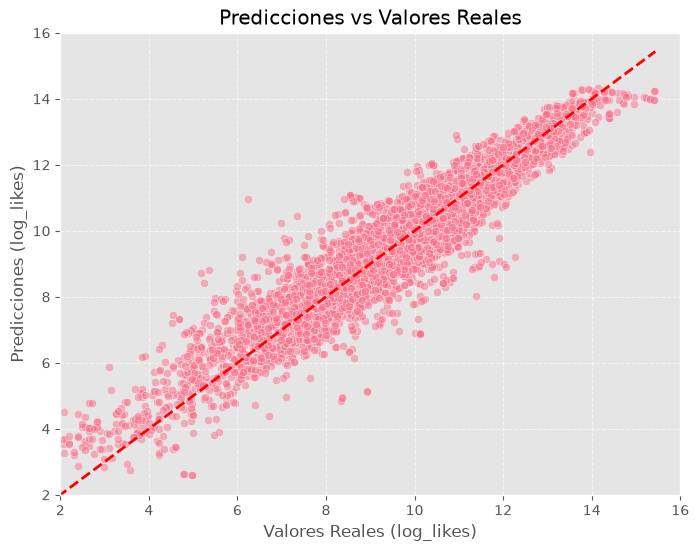

In [103]:
# 4.1 Desarrollo del gráfico
plt.figure(figsize=(8, 6))
plt.scatter(y_test_np, y_pred_np, alpha=0.5, edgecolor='w', linewidth=0.5)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2)

plt.xlim(2, 16)  
plt.ylim(2, 16)  

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Valores Reales (log_likes)')
plt.ylabel('Predicciones (log_likes)')
plt.title('Predicciones vs Valores Reales')
plt.show()

## 5. Interpretación de Coeficientes

En este último paso, extraemos los pesos (coeficientes) que el algoritmo asignó a cada `feature` para identificar qué factores impactan en la viralidad de un video.

* **Coeficientes positivos:** Indican que la característica impulsa la viralidad; a mayor valor de la variable, se predice un incremento en la cantidad de `likes`.
* **Coeficientes negativos:** Indican que la característica reduce la viralidad; a mayor valor de la variable, se predice una disminución en la cantidad de `likes`.


In [104]:
coeficientes = pd.DataFrame({
    'Variable': cat_numericas + cat_binarias,
    'Coeficiente': model.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("Impacto de las variables en la predicción de log_likes:")
display(coeficientes)

Impacto de las variables en la predicción de log_likes:


,Variable,Coeficiente
12,catgrupo_Alto,1.141321
0,log_views,1.029724
11,catgrupo_MedioAlto,0.879518
2,log_comments,0.595614
10,catgrupo_MedioBajo,0.288463
1,log_dislikes,0.283184
4,comment_view_ratio,0.101447
7,n_tags,0.006893
8,first_trend,0.005726
5,log_days_to_trend,-0.072070
